In [3]:
import os 
import sys 

# Manually set the project root directory
project_root = "/home/aladin/latest/resilient_sfl"  # Update this to the actual path
os.chdir(project_root)

# Add the project root to the Python path
if project_root not in sys.path:
    sys.path.append(project_root)


from src.utils.plotting import accumulate_client_metrics, accumulate_master_metrics
import os
import pandas as pd
import matplotlib.pyplot as plt
import os
import yaml
from omegaconf import OmegaConf, DictConfig
from typing import List, Dict


import os
import pandas as pd

import matplotlib.pyplot as plt
import yaml
from matplotlib.image import imread
from omegaconf import OmegaConf, DictConfig
import tikzplotlib

from typing import List, Dict, Optional

import rootutils
# rootutils.setup_root(__file__, indicator=".project-root", pythonpath=True)
from src.utils.plotting import accumulate_client_metrics, accumulate_master_metrics

from IPython.display import display, clear_output
import time 


def fetch_relevant_directories(main_dir: str, dataset: str, model: str) -> list:
    """
    Traverse the main directory and fetch subdirectories that match the dataset and model criteria.
    
    Parameters:
    - main_dir (str): Path to the main directory.
    - dataset (str): Target dataset.
    - model (str): Target model.

    Returns:
    - list: List of subdirectories that match the criteria.
    """
    matched_dirs = []
    
    # List all subdirectories in the main directory
    subdirs = [d for d in os.listdir(main_dir) if os.path.isdir(os.path.join(main_dir, d))]
    
    for subdir in subdirs:

        tags_path = os.path.join(main_dir, subdir, "tags.log")

        if os.path.exists(tags_path):
            with open(tags_path, 'r') as file:
                content = file.read()

                # Extracting tags from the content
                tags = [tag.strip() for tag in content.strip("[]").split(",")]
                if dataset in tags[0] and model in tags[1]:
                    matched_dirs.append(os.path.join(main_dir, subdir))
    
    return matched_dirs


def fetch_configuration(directory: str) -> DictConfig:
    """
    Fetch and interpret the configuration from `config_tree.yaml` in the given directory.
    
    Parameters:
    - directory (str): Path to the target directory.

    Returns:
    - DictConfig: Configuration dictionary.
    """
    config_path = os.path.join(directory, "config_tree.yaml")
    
    with open(config_path, 'r') as file:
        config = yaml.safe_load(file)
    
    return OmegaConf.create(config)


def generate_multiplot(main_dir: str, dataset: str, model: str, client_name="client_0", plot_name="multiplot.png"):
    """
    Generate a multiplot for all the subfolders that match the given dataset and model.
    """
    # Fetch all relevant directories based on the dataset and model
    directories = fetch_relevant_directories(main_dir, dataset, model)
    
    # Number of directories fetched
    num_dirs = len(directories)
    
    # Calculate the layout for the subplots
    cols = 2
    rows = (num_dirs + 1) // cols
    
    # Create the main figure for multiplot
    fig, axes = plt.subplots(rows, cols, figsize=(15, 5 * rows))
    
    for idx, directory in enumerate(directories):
        # Fetch the configuration for the current directory
        config = fetch_configuration(directory)

        # Handle relative paths
        relative_path_components = config.paths.client_log_path.split('/logs/', 1)[-1].split("/")
        relative_path = os.path.join(*relative_path_components[3:4])
        relative_path = os.path.join(relative_path, 'logs/')  
        config.paths.log_path = os.path.join(main_dir, relative_path)

        # Fetch the scenario from the config or tags.log
        scenario = config.tags[-1] if "tags" in config else None
        if not scenario:
            with open(os.path.join(directory, "tags.log"), 'r') as file:
                content = file.read()
                tags = [tag.strip() for tag in content.strip("[]").split(",")]
                scenario = tags[-1]

        # Determine the current subplot axis
        ax = axes[idx // cols, idx % cols] if rows > 1 else axes[idx % cols]

        # Plot the metrics for the current directory on the current subplot axis
        client_train_df, client_val_df = accumulate_client_metrics(config, client_name + "_logger", config.paths.log_path)
        master_train_df, master_val_df = accumulate_master_metrics(config, config.paths.log_path)

        # Extracting parameters from the configuration
        task = config.task_name
        if task == "sc":
            # Plot val metrics for client and master model for sequence classification
            ax.plot(client_val_df['epoch'], client_val_df['val_acc'], label=f'{client_name}', color='blue', linestyle='-', marker='o')
            ax.plot(master_val_df['epoch'], master_val_df['test_acc'], label='Global SFL Model', color='red', linestyle='-', marker='o')
            
            ax.set_ylabel('Accuracy')
        
        elif task == "ner":
            # Plot F1 score metrics for client and master model for NER            
            ax.plot(client_val_df['epoch'], client_val_df['val_f1'], label=f'{client_name}', color='blue', linestyle='-', marker='o')
            ax.plot(master_val_df['epoch'], master_val_df['test_f1'], label='Global SFL Model', color='red', linestyle='-', marker='o')
            
            ax.set_ylabel('F1 Score')
        
        # Set the y-axis scale
        ax.set_ylim(0.4, 1)

        # Set scenario titles
        title_mapping = {
            "None": "Baseline Performance without the Wireless Channel",
            "no_jammer": "No Jamming, only Wireless Impairments",
            "no_protection": "Adversarial Jamming without Protection",
            "w_protection": "Adversarial Jamming with Protection",
        }
        ax.set_title(title_mapping.get(scenario, "Baseline Performance without the Wireless Channel"))
        
        ax.set_xlabel('Cumulative Epochs')
        ax.grid(True, alpha=0.5)
    
    # Remove any unused subplots
    for j in range(idx + 1, rows * cols):
        fig.delaxes(axes.flatten()[j])

    # Add a single legend for the whole figure
    lines, labels = ax.get_legend_handles_labels()
    fig.legend(lines, labels, loc='lower center', fancybox=True, shadow=True, ncol=2)

    # Title
    main_title_fontsize = 20
    subtext_fontsize = 12
    model = config.tags[1].split("_")[0]
    model_task = "Sequence Classification" if task == "sc" else "Named Entity Recognition"
    dataset_name = config.tags[0]
    num_labels = config.model.config.num_labels
    num_clients = config.sfl.num_clients
    num_epochs = config.sfl.num_epochs
    num_rounds = config.sfl.num_rounds

    if task == "sc":
        main_title = 'Classification Accuracies across Global Rounds and Epochs'

    elif task == "ner":
        main_title = 'F1 Scores across Global Rounds and Epochs'

    # fig.suptitle('Classification Accuracies across Global Rounds and Epochs', fontsize=20)
    subtext = f"Model Type: {model}, Model Task: {model_task}, Dataset: {dataset_name}, Number of Labels: {num_labels}, Number of Clients: {num_clients}, Number of Epochs: {num_epochs}, Number of SFL Rounds: {num_rounds}" 
    
    fig.suptitle(main_title, fontsize=main_title_fontsize)
    fig.text(0.5, 0.92, subtext, ha='center', va='center', fontsize=subtext_fontsize)
    # fig.text(0.5, 0.92, 'Your Sub-Title Here', ha='center', va='center', fontsize=16)

    # Tight layout and save the multiplot
    plt.tight_layout()

    # Adjust spacing and layout
    # plt.subplots_adjust(bottom=0.1)
    plt.subplots_adjust(bottom=0.1, top=0.85)

    plt.savefig(os.path.join(main_dir, plot_name))


def generate_joint_bar_plot(main_dir: str, 
                            dataset: str, 
                            model: str, 
                            plot_data: str = "client", 
                            client_name="client_0", 
                            plot_name="barplot.png"):
    """
    Generate a joint bar plot for all subfolders that match the given dataset and model.
    """
    # Fetch all relevant directories based on the dataset and model
    directories = fetch_relevant_directories(main_dir, dataset, model)
    
    # Create the main figure for the bar plot
    fig, ax = plt.subplots(figsize=(15, 7))
    
    # Lists to store bar plot data
    scenarios = []
    client_metrics = []
    master_metrics = []
    
    # Loop through each directory and accumulate data
    for directory in directories:
        # Fetch the configuration for the current directory
        config = fetch_configuration(directory)

        # Handle relative paths
        relative_path_components = config.paths.client_log_path.split('/logs/', 1)[-1].split("/")
        relative_path = os.path.join(*relative_path_components[3:4])
        relative_path = os.path.join(relative_path, 'logs/')  
        config.paths.log_path = os.path.join(main_dir, relative_path)

        # Handle potential errors while fetching scenario
        try:
            scenario = config.tags[-1] if "tags" in config else None
            if not scenario:
                with open(os.path.join(directory, "tags.log"), 'r') as file:
                    content = file.read()
                    tags = [tag.strip() for tag in content.strip("[]").split(",")]
                    scenario = tags[-1]
        except Exception as e:
            print(f"Error fetching scenario for directory {directory}: {e}")
            continue
        
        # Fetch metrics for the current directory
        client_train_df, client_val_df = accumulate_client_metrics(config, client_name + "_logger", config.paths.log_path)
        master_train_df, master_val_df = accumulate_master_metrics(config, config.paths.log_path)
        
        # Extracting task from the configuration
        task = config.get("task_name", "")
        
        # Plot client data based on the task
        label_mapping = {
            "None": "Baseline Performance without the Wireless Channel",
            "no_jammer": "No Jamming, only Wireless Impairments",
            "no_protection": "Adversarial Jamming without Protection",
            "w_protection": "Adversarial Jamming with Protection",
        }

        # label_scenario = label_mapping.get(scenario, scenario)
        label_scenario = label_mapping.get(scenario, scenario).replace(", ", ",\n")

        scenarios.append(label_scenario)
        
        # Accumulate metrics for bar plotting
        if task == "sc":
            client_metrics.append(client_val_df['val_acc'].iloc[-1]) 
            master_metrics.append(master_val_df['test_acc'].iloc[-1])
        elif task == "ner":
            client_metrics.append(client_val_df['val_f1'].iloc[-1])
            master_metrics.append(master_val_df['test_f1'].iloc[-1])

    # Plotting bars
    bar_width = 0.35
    indices = list(range(len(scenarios)))
    
    if plot_data in ["client", "both"]:
        ax.bar(indices, client_metrics, bar_width, label='Client Model', alpha=0.8)
        
    if plot_data in ["master", "both"]:
        # If both client and master data are plotted, shift master bars to the right for clarity
        if plot_data == "both":
            indices = [i + bar_width for i in indices]
        ax.bar(indices, master_metrics, bar_width, label='Global SFL Model', alpha=0.8)
    
    # Formatting
    ax.set_ylim(0.4, 1)
    ax.set_xlabel('Scenarios')
    ax.set_ylabel('Metric Value')
    ax.set_xticks([i + bar_width/2 for i in range(len(scenarios))])
    # ax.set_xticklabels(scenarios, rotation=30, ha='right')
    ax.set_xticklabels(scenarios, ha='center')

    # Set title
    main_title_fontsize = 16
    subtitle_fontsize = 10
    model = config.tags[1].split("_")[0]
    model_task = "Sequence Classification" if task == "sc" else "Named Entity Recognition"
    dataset_name = config.tags[0]
    num_labels = config.model.config.num_labels
    num_clients = config.sfl.num_clients
    num_epochs = config.sfl.num_epochs
    num_rounds = config.sfl.num_rounds

    if task == "sc":
        main_title = 'Classification Accuracies across Global Rounds and Epochs'

    elif task == "ner":
        main_title = 'F1 Scores across Global Rounds and Epochs'

    subtitle = f"Model Type: {model}, Model Task: {model_task}, Dataset: {dataset_name}, Number of Labels: {num_labels}, Number of Clients: {num_clients}, Number of Epochs: {num_epochs}, Number of SFL Rounds: {num_rounds}"
    plt.suptitle(main_title, fontsize=main_title_fontsize)  
    plt.title(subtitle, fontsize=subtitle_fontsize)

    ax.grid(True, alpha=0.5)
    # ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.10), fancybox=True, shadow=True, ncol=4)
    ax.legend(loc='upper right', fancybox=True, shadow=True, ncol=2)
    plt.subplots_adjust(bottom=0.25)

    # Adjust spacing and layout
    plt.tight_layout()

    plt.savefig(os.path.join(main_dir, plot_name))



def generate_joint_plot(main_dir: str, 
                        dataset: str, 
                        model: str, 
                        plot_data: str = "client", 
                        client_name="client_0", 
                        plot_name="jointplot.png",
                        ax=None):
    """
    Generate a joint plot for all subfolders that match the given dataset and model.
    
    Parameters:
    - main_dir: Main directory path.
    - dataset: Dataset name.
    - model: Model name.
    - plot_data: A string which can be "client", "master", or "both" to decide which data to plot.
    - client_name: The name of the client.
    - plot_name: The name of the saved plot.
    
    """
    # Fetch all relevant directories based on the dataset and model
    directories = fetch_relevant_directories(main_dir, dataset, model)

    # Create the main figure for the joint plot
    ax_provided = True
    if ax is None:
        fig, ax = plt.subplots(figsize=(15, 7))
        ax_provided = False

    # Loop through each directory and plot the data
    for directory in directories:
        # Fetch the configuration for the current directory
        config = fetch_configuration(directory)

        # Handle relative paths
        relative_path_components = config.paths.client_log_path.split('/logs/', 1)[-1].split("/")
        relative_path = os.path.join(*relative_path_components[3:4])
        relative_path = os.path.join(relative_path, 'logs/')  
        config.paths.log_path = os.path.join(main_dir, relative_path)

        # Handle potential errors while fetching scenario
        try:
            scenario = config.tags[-1] if "tags" in config else None
            if not scenario:
                with open(os.path.join(directory, "tags.log"), 'r') as file:
                    content = file.read()
                    tags = [tag.strip() for tag in content.strip("[]").split(",")]
                    scenario = tags[-1]
        except Exception as e:
            print(f"Error fetching scenario for directory {directory}: {e}")
            continue
        
        # Fetch metrics for the current directory
        client_train_df, client_val_df = accumulate_client_metrics(config, client_name + "_logger", config.paths.log_path)
        master_train_df, master_val_df = accumulate_master_metrics(config, config.paths.log_path)
        
        # Extracting task from the configuration
        task = config.get("task_name", "")
        
        # Plot client data based on the task
        label_mapping = {
            "None": "Baseline Performance without the Wireless Channel",
            "no_jammer": "No Jamming, only Wireless Impairments",
            "no_protection": "Adversarial Jamming without Protection",
            "w_protection": "Adversarial Jamming with Protection",
        }
        label_scenario = label_mapping.get(scenario, scenario)

        if plot_data in ["client", "both"]:
            if task == "sc":
                ax.plot(client_val_df['epoch'].to_numpy(), client_val_df['val_acc'].to_numpy(), label=f'{label_scenario}', linestyle='-', marker='o')
            elif task == "ner":
                ax.plot(client_val_df['epoch'].to_numpy(), client_val_df['val_f1'].to_numpy(), label=f'{label_scenario}', linestyle='-', marker='o')
        
        # Plot master data based on the task
        if plot_data in ["master", "both"]:
            if task == "sc":
                ax.plot(master_val_df['epoch'].to_numpy(), master_val_df['test_acc'].to_numpy(), label=f'{label_scenario}', linestyle='--', marker='x')
            elif task == "ner":
                ax.plot(master_val_df['epoch'].to_numpy(), master_val_df['test_f1'].to_numpy(), label=f'{label_scenario}', linestyle='--', marker='x')

    # Set the axis parameters
    ax.set_ylim(0.4, 1)
    ax.set_xlabel('Cumulative Epochs')

    # Set title
    main_title_fontsize = 16
    subtitle_fontsize = 10
    model = config.tags[1].split("_")[0]
    model_task = "Sequence Classification" if task == "sc" else "Named Entity Recognition"
    dataset_name = config.tags[0]
    num_labels = config.model.config.num_labels
    num_clients = config.sfl.num_clients
    num_epochs = config.sfl.num_epochs
    num_rounds = config.sfl.num_rounds

    if task == "sc":
        ax.set_ylabel('Accuracy')
        main_title = 'Classification Accuracies across Global Rounds and Epochs'

    elif task == "ner":
        ax.set_ylabel('F1 Score')
        main_title = 'F1 Scores across Global Rounds and Epochs'

    subtitle = f"Model Type: {model}, Model Task: {model_task}, Dataset: {dataset_name}, Number of Labels: {num_labels}, Number of Clients: {num_clients}, Number of Epochs: {num_epochs}, Number of SFL Rounds: {num_rounds}"
    plt.suptitle(main_title, fontsize=main_title_fontsize)  
    plt.title(subtitle, fontsize=subtitle_fontsize) 

    ax.grid(True, alpha=0.5)
    # ax.legend(loc='lower center', fancybox=True, shadow=True, ncol=4)
    ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.10), fancybox=True, shadow=True, ncol=4)
    plt.subplots_adjust(bottom=0.25)


    # Adjust spacing and layout
    plt.tight_layout()

    # plt.savefig(os.path.join(main_dir, plot_name))
    if not ax_provided:
        plt.savefig(os.path.join(main_dir, plot_name))



def generate_joint_multiplot(main_dir: str,
                             base_model: str,
                             sc_datasets: List[str],
                             ner_datasets: List[str],
                             plot_data: str = "client",
                             client_name: str = "client_0",
                             save_dir: str = "./",
                             plot_name: str = "jointmultiplot.png"):
    """
    Generate a joint multiplot for all subfolders that match the given datasets and model.
    
    Parameters:
    - main_dir: Main directory path.
    - base_model: Base model name (e.g., 'roberta' or 'bert').
    - sc_datasets: List of SC dataset names.
    - ner_datasets: List of NER dataset names.
    - plot_data: A string which can be "client", "master", or "both" to decide which data to plot.
    - client_name: The name of the client.
    - plot_name: The name of the saved plot.
    """
    
    # Model Mapping
    model_mapping: Dict[str, Dict[str, str]] = {
        'roberta': {
            'sc': 'roberta_for_sequence_classification',
            'ner': 'roberta_for_token_classification'
        },
        'bert': {
            'sc': 'bert_for_sequence_classification',
            'ner': 'bert_for_token_classification'
        }
    }
    
    # Label Mapping
    label_mapping: Dict[str, str] = {
        "None": "Baseline Performance without the Wireless Channel",
        "no_jammer": "No Jamming, only Wireless Impairments",
        "no_protection": "Adversarial Jamming without Protection",
        "w_protection": "Adversarial Jamming with Protection"
    }

    # Create a 2x2 subplot
    fig, axs = plt.subplots(2, 2, figsize=(20, 14))
    
    # Get the list of subdirectories in main_dir
    subdirs: List[str] = [os.path.join(main_dir, d) for d in os.listdir(main_dir) if os.path.isdir(os.path.join(main_dir, d))]

    # Initialize an empty set to store unique legend labels
    legend_entries = {}

    # Function to handle plotting for both SC and NER datasets
    def plot_data_for_dataset(row: int, col: int, dataset: str, task: str):
        model = model_mapping[base_model][task]
        metric = 'acc' if task == 'sc' else 'f1'
        ylabel = r'Accuracy' if task == 'sc' else r'F1 Score'
        
        for subdir in subdirs:
            directories = fetch_relevant_directories(subdir, dataset, model)
            if not directories:
                continue

            for directory in directories:
                # Fetch the configuration for the current directory
                config = fetch_configuration(directory)

                # Handle relative paths
                relative_path_components = config.paths.client_log_path.split('/logs/', 1)[-1].split("/")
                relative_path = os.path.join(*relative_path_components[3:4])
                relative_path = os.path.join(relative_path, 'logs/')  
                config.paths.log_path = os.path.join(subdir, relative_path)

                # Get scenario
                try:
                    scenario = config.tags[-1] if "tags" in config else None
                    if not scenario:
                        with open(os.path.join(directory, "tags.log"), 'r') as file:
                            content = file.read()
                            tags = [tag.strip() for tag in content.strip("[]").split(",")]
                            scenario = tags[-1]
                except Exception as e:
                    print(f"Error fetching scenario for directory {directory}: {e}")
                    continue

                # Fetch metrics for the current directory
                client_train_df, client_val_df = accumulate_client_metrics(config, client_name + "_logger", config.paths.log_path)
                master_train_df, master_val_df = accumulate_master_metrics(config, config.paths.log_path)

                # Plot data
                ax = axs[row][col]
                label_scenario = label_mapping.get(scenario, scenario)

                label = f'{label_scenario}'
                if plot_data in ["client", "both"]:
                    line1, = ax.plot(client_val_df['epoch'].to_numpy(), client_val_df[f'val_{metric}'].to_numpy(), label=f'{label_scenario}', linestyle='-', marker='o')
                    legend_entries[label] = line1
                
                if plot_data in ["master", "both"]:
                    line2, = ax.plot(master_val_df['epoch'].to_numpy(), master_val_df[f'test_{metric}'].to_numpy(), label=f'{label_scenario}', linestyle='--', marker='x')
                    legend_entries[label] = line2

                # Set the axis parameters for the subplot
                ax.set_ylim(0., 1) if task == 'sc' or dataset == "conll2003" else ax.set_ylim(0.05, 0.5)
                ax.set_xlabel(r'Cumulative Epochs', fontsize=14)
                ax.set_ylabel(ylabel, fontsize=14)
                ax.set_title(f'{dataset.upper()}',  fontsize=16)
                ax.grid(True, alpha=0.5)

    # Process SC datasets
    for idx, dataset in enumerate(sc_datasets):
        plot_data_for_dataset(0, idx, dataset, 'sc')

    # Process NER datasets
    for idx, dataset in enumerate(ner_datasets):
        plot_data_for_dataset(1, idx, dataset, 'ner')

    fig.legend(handles=legend_entries.values(), 
               labels=legend_entries.keys(), 
               loc='lower center', 
               ncol=len(legend_entries), 
               fancybox=True, 
               shadow=True,
               fontsize=14)
    
    fig.suptitle(r'Performance Metrics for SC and NER NLP Tasks', fontsize=18, fontweight='bold')


    # Set global title, layout, and save figure
    plt.tight_layout()
    plt.subplots_adjust(hspace=0.2, wspace=0.1, bottom=0.09)  
    plt.savefig(os.path.join(save_dir, plot_name))




def generate_jointplot_tikz(main_dir: str, 
                            dataset: str, 
                            model: str, 
                            client_name="client_0", 
                            plot_name="jointplot.png", 
                            lims: list = [0.4, 1]):
    """
    Generate a joint plot for all subfolders that match the given dataset and model, using LaTeX font.
    """
    # Font size configuration
    common_font_size = 16
    axis_ticks_font_size = 16

    # Define known scenarios and their display names
    scenario_display_names = {
        "None": "SFL Baseline",
        "no_jammer": "Gaussian",
        "no_protection": "No Protection",
        "w_protection": "Protection"
    }

    # scenario_display_names = {
    #     "None": "No Wireless Channel",
    #     "no_jammer": "No Attack, only Wireless Impairments",
    #     "no_protection": "Adversarial Attack without Protection",
    #     "w_protection": "Adversarial Attack with Protection"
    # }

    # Fetch all relevant directories based on the dataset and model
    directories = fetch_relevant_directories(main_dir, dataset, model)

    # Create the main figure for joint plot
    fig, ax = plt.subplots(figsize=(15, 10))

    # colors = ['blue', 'red', 'green', 'purple', 'orange', 'brown']
    colors = ['blue', 'red', 'orange', 'green', 'purple', 'brown']
    client_mapping = {
        "client_0": "Client 1",
        "client_1": "Client 2",
        "client_2": "Client 3",
    }

    scenario_colors = {
        "None": "orange",
        "no_jammer": "green",
        "no_protection": "red",
        "w_protection": "blue"
    }

    # Assume configuration is the same for all directories
    if directories:
        config = fetch_configuration(directories[0])

    model_name = config.tags[1].split("_")[0]
    model_task = "Sequence Classification" if config.task_name == "sc" else "Named Entity Recognition"
    dataset_name = config.tags[0]
    num_labels = config.model.config.num_labels
    num_clients = config.sfl.num_clients
    num_epochs = config.sfl.num_epochs
    num_rounds = config.sfl.num_rounds

    for idx, directory in enumerate(directories):
        config = fetch_configuration(directory)

        # Handle relative paths
        relative_path_components = config.paths.client_log_path.split('/logs/', 1)[-1].split("/")
        relative_path = os.path.join(*relative_path_components[3:4])
        relative_path = os.path.join(relative_path, 'logs/')  
        config.paths.log_path = os.path.join(main_dir, relative_path)

        scenario = None
        if "tags" in config:
            for tag in config.tags:
                if tag in scenario_display_names:
                    scenario = tag
                    break

        if not scenario:
            with open(os.path.join(directory, "tags.log"), 'r') as file:
                content = file.read()
                tags = [tag.strip() for tag in content.strip("[]").split(",")]
                for tag in tags:
                    if tag in scenario_display_names:
                        scenario = tag
                        break

        client_train_df, client_val_df = accumulate_client_metrics(config, client_name + "_logger", config.paths.log_path)
        master_train_df, master_val_df = accumulate_master_metrics(config, config.paths.log_path)

        display_name = client_mapping.get(client_name, client_name)

        # color = colors[idx % len(colors)]
        color = scenario_colors.get(scenario, 'black')  # Use 'black' as default if scenario is not found


        if config.task_name == "sc":
            ax.plot(client_val_df['epoch'].to_numpy(), client_val_df['val_acc'].to_numpy(), label=f'{display_name} - {scenario_display_names[scenario]}', color=color, linestyle='-', marker='o')
            ax.set_ylabel('Accuracy', fontsize=common_font_size)
        elif config.task_name == "ner":
            ax.plot(client_val_df['epoch'].to_numpy(), client_val_df['val_f1'].to_numpy(), label=f'{display_name} - {scenario_display_names[scenario]}', color=color, linestyle='-', marker='o')
            ax.set_ylabel('F1 Score', fontsize=common_font_size)

        ax.set_ylim(lims)


        ax.tick_params(axis='both', labelsize=axis_ticks_font_size)

        main_title = 'Classification Accuracies across Global Rounds and Epochs' if config.task_name == "sc" else 'F1 Scores across Global Rounds and Epochs'
        main_title = 'SST2 ROBERTA'

        main_title = f'{dataset_name.upper()} {model_name.upper()}'
        
        subtitle = f"Model Type: {model_name}, Model Task: {model_task}, Dataset: {dataset_name}, Number of Labels: {num_labels}, Number of Clients: {num_clients}, Number of Epochs: {num_epochs}, Number of SFL Rounds: {num_rounds}"

        main_title_fontsize = 24
        subtitle_fontsize = 14
        # plt.suptitle(main_title,fontsize=main_title_fontsize)
        # plt.title(subtitle, fontsize=subtitle_fontsize)
        plt.title(main_title, fontsize=main_title_fontsize, pad=20)

        ax.set_xlabel('Cumulative Epochs', fontsize=common_font_size)
        ax.grid(True, alpha=1)

        # Position the legend outside the plot
        # ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), fancybox=True, shadow=True, ncol=4, fontsize=common_font_size)

        # Tight layout and save the joint plot
        plt.tight_layout()
        plt.subplots_adjust(bottom=0.25, top=0.85)

        tikz_save_path = os.path.join(main_dir, "jointplot.tex")
        tikzplotlib.save(tikz_save_path)
        print(tikz_save_path)

        save_fig(fig, os.path.join(main_dir, plot_name), latex=True, pdf=True)


def generate_jointplot_tikz_interactive(main_dir: str, 
                            dataset: str, 
                            model: str, 
                            client_name="client_0", 
                            plot_name="jointplot.png", 
                            lims: list = [0.4, 1]):
    """
    Generate a joint plot for all subfolders that match the given dataset and model, using LaTeX font.
    """
    # Font size configuration
    common_font_size = 16
    axis_ticks_font_size = 16

    # Define known scenarios and their display names
    scenario_display_names = {
        "None": "SFL Baseline",
        "no_jammer": "Gaussian",
        "no_protection": "No Protection",
        "w_protection": "Protection"
    }

    # Define scenario-to-color mapping
    scenario_colors = {
        "None": "orange",
        "no_jammer": "green",
        "no_protection": "red",
        "w_protection": "blue"
    }

    # Fetch all relevant directories based on the dataset and model
    directories = fetch_relevant_directories(main_dir, dataset, model)

    # Create the main figure for joint plot
    fig, ax = plt.subplots(figsize=(15, 10))

    client_mapping = {
        "client_0": "Client 1",
        "client_1": "Client 2",
        "client_2": "Client 3",
    }

    # Assume configuration is the same for all directories
    if directories:
        config = fetch_configuration(directories[0])

    model_name = config.tags[1].split("_")[0]
    model_task = "Sequence Classification" if config.task_name == "sc" else "Named Entity Recognition"
    dataset_name = config.tags[0]
    num_labels = config.model.config.num_labels
    num_clients = config.sfl.num_clients
    num_epochs = config.sfl.num_epochs
    num_rounds = config.sfl.num_rounds

    plt.ion()  # Turn on interactive mode

    for idx, directory in enumerate(directories):
        config = fetch_configuration(directory)

        # Handle relative paths
        relative_path_components = config.paths.client_log_path.split('/logs/', 1)[-1].split("/")
        relative_path = os.path.join(*relative_path_components[3:4])
        relative_path = os.path.join(relative_path, 'logs/')  
        config.paths.log_path = os.path.join(main_dir, relative_path)

        scenario = None
        if "tags" in config:
            for tag in config.tags:
                if tag in scenario_display_names:
                    scenario = tag
                    break

        if not scenario:
            with open(os.path.join(directory, "tags.log"), 'r') as file:
                content = file.read()
                tags = [tag.strip() for tag in content.strip("[]").split(",")]
                for tag in tags:
                    if tag in scenario_display_names:
                        scenario = tag
                        break

        client_train_df, client_val_df = accumulate_client_metrics(config, client_name + "_logger", config.paths.log_path)
        master_train_df, master_val_df = accumulate_master_metrics(config, config.paths.log_path)

        display_name = client_mapping.get(client_name, client_name)
        color = scenario_colors.get(scenario, 'black')  # Use 'black' as default if scenario is not found

        epochs = client_val_df['epoch'].to_numpy()
        if config.task_name == "sc":
            vals = client_val_df['val_acc'].to_numpy()
            ylabel = 'Accuracy'
        elif config.task_name == "ner":
            vals = client_val_df['val_f1'].to_numpy()
            ylabel = 'F1 Score'

        for i in range(len(epochs)):
            ax.plot(epochs[:i+1], vals[:i+1], label=f'{display_name} - {scenario_display_names[scenario]}', color=color, linestyle='-', marker='o')
            ax.set_ylabel(ylabel, fontsize=common_font_size)
            ax.set_ylim(lims)
            ax.set_xlabel('Cumulative Epochs', fontsize=common_font_size)
            ax.grid(True, alpha=1)
            ax.tick_params(axis='both', labelsize=axis_ticks_font_size)

            main_title = f'{dataset_name.upper()} {model_name.upper()}'
            plt.title(main_title, fontsize=24, pad=20)

            ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), fancybox=True, shadow=True, ncol=4, fontsize=common_font_size)
            plt.tight_layout()
            plt.subplots_adjust(bottom=0.25, top=0.85)

            display(fig)
            clear_output(wait=True)
            time.sleep(0.5)

    plt.ioff()  # Turn off interactive mode

    tikz_save_path = os.path.join(main_dir, "jointplot.tex")
    tikzplotlib.save(tikz_save_path)
    print(tikz_save_path)

    save_fig(fig, os.path.join(main_dir, plot_name), latex=True, pdf=True)


def save_fig(f, save_path: str | os.PathLike, latex: bool = False, pdf: bool = False, **kwargs):
    """
    Saves the figure to the specified path with the given format options.
    """
    stem = os.path.split(save_path)[0]
    if not os.path.isdir(stem):
        os.mkdir(stem)
    f.savefig(
        os.path.join(save_path + ".png"),
        dpi=150,
        bbox_inches="tight",
        **kwargs,
    )
    if pdf:
        f.savefig(
            os.path.join(save_path + ".pdf"),
            dpi=150,
            bbox_inches="tight",
            **kwargs,
        )
    if latex:
        tikzplotlib.save(
            os.path.join(save_path + ".tex"),
            figure=f,
            strict=False,
            **kwargs,
        )


def generate_single_plot_tikz(main_dir: str, 
                              dataset: str, 
                              model: str, 
                              client_name="client_0", 
                              plot_name="singleplot.png"):
    """
    Generate a single plot for all subfolders that match the given dataset and model.
    """
    # Define known scenarios
    known_scenarios = ["None", "no_jammer", "no_protection", "w_protection"]

    # Fetch all relevant directories based on the dataset and model
    directories = fetch_relevant_directories(main_dir, dataset, model)

    # Create the main figure for the single plot
    fig, ax = plt.subplots(figsize=(15, 10))

    for idx, directory in enumerate(directories):
        # Fetch the configuration for the current directory
        config = fetch_configuration(directory)

        # Handle relative paths
        relative_path_components = config.paths.client_log_path.split('/logs/', 1)[-1].split("/")
        relative_path = os.path.join(*relative_path_components[3:4])
        relative_path = os.path.join(relative_path, 'logs/')  
        config.paths.log_path = os.path.join(main_dir, relative_path)

        # Fetch the scenario from the config or tags.log
        scenario = None
        if "tags" in config:
            for tag in config.tags:
                if tag in known_scenarios:
                    scenario = tag
                    break

        if not scenario:
            with open(os.path.join(directory, "tags.log"), 'r') as file:
                content = file.read()
                tags = [tag.strip() for tag in content.strip("[]").split(",")]
                for tag in tags:
                    if tag in known_scenarios:
                        scenario = tag
                        break

        # Plot the metrics for the current directory on the single subplot axis
        client_train_df, client_val_df = accumulate_client_metrics(config, client_name + "_logger", config.paths.log_path)
        master_train_df, master_val_df = accumulate_master_metrics(config, config.paths.log_path)

        # CLient mapping
        client_mapping = {
            "client_0": "Client 1",
            "client_1": "Client 2",
            "client_2": "Client 3",
        }

        # Apply client mapping to client_name
        display_name = client_mapping.get(client_name, client_name)

        # Add plots to the single axis
        task = config.task_name
        if task == "sc":
            ax.plot(client_val_df['epoch'].to_numpy(), client_val_df['val_acc'].to_numpy(), label=f'{display_name} ({scenario})', linestyle='-', marker='o')
            ax.plot(master_val_df['epoch'].to_numpy(), master_val_df['test_acc'].to_numpy(), label=f'Global SFL Model ({scenario})', linestyle='-', marker='o')
            ax.set_ylabel('Accuracy', fontsize=12)
        
        elif task == "ner":
            ax.plot(client_val_df['epoch'].to_numpy(), client_val_df['val_f1'].to_numpy(), label=f'{display_name} ({scenario})', linestyle='-', marker='o')
            ax.plot(master_val_df['epoch'].to_numpy(), master_val_df['test_f1'].to_numpy(), label=f'Global SFL Model ({scenario})', linestyle='-', marker='o')

            ax.set_ylabel('F1 Score', fontsize=12)

    # Set labels for the single axis
    ax.set_ylim(0.4, 1)
    
    # Size adjustments
    ax.tick_params(axis='x', labelsize=12)
    ax.tick_params(axis='y', labelsize=12)

    ax.set_xlabel('Cumulative Epochs', fontsize=12)

    # ax.set_xlabel('Cumulative Epochs')
    ax.grid(True, alpha=1)
    
    # Add a single legend for the whole figure
    lines, labels = ax.get_legend_handles_labels()
    
    fig.legend(lines, labels, loc='lower center', fancybox=True, shadow=True, ncol=2, fontsize=12)

    # Title
    main_title_fontsize = 20
    subtext_fontsize = 12
    model = config.tags[1].split("_")[0]
    model_task = "Sequence Classification" if task == "sc" else "Named Entity Recognition"
    dataset_name = config.tags[0]

    # make adataset name all capital
    dataset_name = dataset_name.upper()

    # make model name all capital
    model = model.upper()

    num_labels = config.model.config.num_labels
    num_clients = config.sfl.num_clients
    num_epochs = config.sfl.num_epochs
    num_rounds = config.sfl.num_rounds
    batch_size = config.datamodule.batch_size

    if task == "sc":
        main_title = 'Classification Accuracies across Global Rounds and Epochs'

    elif task == "ner":
        main_title = 'F1 Scores across Global Rounds and Epochs'

    # fig.suptitle('Classification Accuracies across Global Rounds and Epochs', fontsize=20)
    subtext = f"Model Type: {model}, Model Task: {model_task}, Dataset: {dataset_name}, Batch Size: {batch_size}, Number of Clients: {num_clients}, Number of Epochs: {num_epochs}, Number of SFL Rounds: {num_rounds}" 
    
    fig.suptitle(main_title, fontsize=main_title_fontsize)
    fig.text(0.5, 0.92, subtext, ha='center', va='center', fontsize=subtext_fontsize)

    # Adjust layout
    plt.tight_layout()
    plt.subplots_adjust(bottom=0.15, top=0.85)

    # Save the single plot
    tikz_save_path = os.path.join(main_dir, "singleplot.tex")
    tikzplotlib.save(tikz_save_path)
    print(tikz_save_path)
    save_fig(fig, save_path=os.path.join(main_dir, plot_name), latex=True, pdf=True)

/home/aladin/latest/resilient_sfl/venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
def generate_single_plot_tikz_new(main_dir: str, 
                              dataset: str, 
                              model: str, 
                              client_names=("client_0", "client_2"),
                              plot_name="singleplot.png"):
    """
    Generate a single plot for all subfolders that match the given dataset and model.
    """
    # Define known scenarios and filter scenario
    known_scenarios = ["None", "no_jammer", "no_protection", "w_protection"]
    filter_scenario = "w_protection"

    # Fetch all relevant directories based on the dataset and model
    directories = fetch_relevant_directories(main_dir, dataset, model)

    # Create the main figure for the single plot
    fig, ax = plt.subplots(figsize=(15, 10))

    for idx, directory in enumerate(directories):
        # Fetch the configuration for the current directory
        config = fetch_configuration(directory)

        # Handle relative paths
        relative_path_components = config.paths.client_log_path.split('/logs/', 1)[-1].split("/")
        relative_path = os.path.join(*relative_path_components[3:4])
        relative_path = os.path.join(relative_path, 'logs/')  
        config.paths.log_path = os.path.join(main_dir, relative_path)

        # Fetch the scenario from the config or tags.log
        scenario = None
        if "tags" in config:
            for tag in config.tags:
                if tag in known_scenarios:
                    scenario = tag
                    break

        if not scenario:
            with open(os.path.join(directory, "tags.log"), 'r') as file:
                content = file.read()
                tags = [tag.strip() for tag in content.strip("[]").split(",")]
                for tag in tags:
                    if tag in known_scenarios:
                        scenario = tag
                        break

        # Only plot for the filtered scenario
        if scenario != filter_scenario:
            continue

        for client_name in client_names:
            # Plot the metrics for the current directory on the single subplot axis
            client_train_df, client_val_df = accumulate_client_metrics(config, client_name + "_logger", config.paths.log_path)
            master_train_df, master_val_df = accumulate_master_metrics(config, config.paths.log_path)

            # Client mapping
            client_mapping = {
                "client_0": "Client 1",
                "client_2": "Client 3",
            }

            # Apply client mapping to client_name
            display_name = client_mapping.get(client_name, client_name)

            # Add plots to the single axis
            task = config.task_name
            if task == "sc":
                if client_name in client_mapping:
                    ax.plot(client_val_df['epoch'].to_numpy(), client_val_df['val_acc'].to_numpy(), label=f'{display_name} ({scenario})', linestyle='-', marker='o')
                if client_name == "client_0":
                    ax.plot(master_val_df['epoch'].to_numpy(), master_val_df['test_acc'].to_numpy(), label=f'Global SFL Model ({scenario})', linestyle='-', marker='o')
                ax.set_ylabel('Accuracy', fontsize=12)

            elif task == "ner":
                if client_name in client_mapping:
                    ax.plot(client_val_df['epoch'].to_numpy(), client_val_df['val_f1'].to_numpy(), label=f'{display_name} ({scenario})', linestyle='-', marker='o')
                if client_name == "client_0":
                    ax.plot(master_val_df['epoch'].to_numpy(), master_val_df['test_f1'].to_numpy(), label=f'Global SFL Model ({scenario})', linestyle='-', marker='o')
                ax.set_ylabel('F1 Score', fontsize=12)

    # Set labels for the single axis
    ax.set_ylim(0.4, 1)
    
    # Size adjustments
    ax.tick_params(axis='x', labelsize=12)
    ax.tick_params(axis='y', labelsize=12)

    ax.set_xlabel('Cumulative Epochs', fontsize=12)
    ax.grid(True, alpha=1)
    
    # Add a single legend for the whole figure
    lines, labels = ax.get_legend_handles_labels()
    fig.legend(lines, labels, loc='lower center', fancybox=True, shadow=True, ncol=2, fontsize=12)

    # Title
    main_title_fontsize = 20
    subtext_fontsize = 12
    model = config.tags[1].split("_")[0]
    model_task = "Sequence Classification" if task == "sc" else "Named Entity Recognition"
    dataset_name = config.tags[0].upper()
    model = model.upper()

    num_labels = config.model.config.num_labels
    num_clients = config.sfl.num_clients
    num_epochs = config.sfl.num_epochs
    num_rounds = config.sfl.num_rounds
    batch_size = config.datamodule.batch_size

    main_title = 'Classification Accuracies across Global Rounds and Epochs' if task == "sc" else 'F1 Scores across Global Rounds and Epochs'

    subtext = f"Model Type: {model}, Model Task: {model_task}, Dataset: {dataset_name}, Batch Size: {batch_size}, Number of Clients: {num_clients}, Number of Epochs: {num_epochs}, Number of SFL Rounds: {num_rounds}" 

    fig.suptitle(main_title, fontsize=main_title_fontsize)
    fig.text(0.5, 0.92, subtext, ha='center', va='center', fontsize=subtext_fontsize)

    # Adjust layout
    plt.tight_layout()
    plt.subplots_adjust(bottom=0.15, top=0.85)

    # Save the single plot
    tikz_save_path = os.path.join(main_dir, "singleplot.tex")
    tikzplotlib.save(tikz_save_path)
    print(tikz_save_path)
    save_fig(fig, save_path=os.path.join(main_dir, plot_name), latex=True, pdf=True)



def generate_single_plot_tikz_new_all(main_dir: str, 
                              dataset: str, 
                              model: str, 
                              client_names=("client_0", "client_1", "client_2"),
                              plot_name="singleplot.png"):
    """
    Generate a single plot for all subfolders that match the given dataset and model.
    """
    # Define known scenarios and filter scenario
    known_scenarios = ["None", "no_jammer", "no_protection", "w_protection"]
    filter_scenario = "w_protection"

    # Fetch all relevant directories based on the dataset and model
    directories = fetch_relevant_directories(main_dir, dataset, model)

    # Create the main figure for the single plot
    fig, ax = plt.subplots(figsize=(15, 10))

    for idx, directory in enumerate(directories):
        # Fetch the configuration for the current directory
        config = fetch_configuration(directory)

        # Handle relative paths
        relative_path_components = config.paths.client_log_path.split('/logs/', 1)[-1].split("/")
        relative_path = os.path.join(*relative_path_components[3:4])
        relative_path = os.path.join(relative_path, 'logs/')  
        config.paths.log_path = os.path.join(main_dir, relative_path)

        # Fetch the scenario from the config or tags.log
        scenario = None
        if "tags" in config:
            for tag in config.tags:
                if tag in known_scenarios:
                    scenario = tag
                    break

        if not scenario:
            with open(os.path.join(directory, "tags.log"), 'r') as file:
                content = file.read()
                tags = [tag.strip() for tag in content.strip("[]").split(",")]
                for tag in tags:
                    if tag in known_scenarios:
                        scenario = tag
                        break

        # Only plot for the filtered scenario
        if scenario != filter_scenario:
            continue

        for client_name in client_names:
            # Plot the metrics for the current directory on the single subplot axis
            client_train_df, client_val_df = accumulate_client_metrics(config, client_name + "_logger", config.paths.log_path)
            master_train_df, master_val_df = accumulate_master_metrics(config, config.paths.log_path)

            # Client mapping
            client_mapping = {
                "client_0": "Client 1",
                "client_1": "Client 2",
                "client_2": "Client 3",
            }

            # Apply client mapping to client_name
            display_name = client_mapping.get(client_name, client_name)

            # Add plots to the single axis
            task = config.task_name
            if task == "sc":
                if client_name in client_mapping:
                    ax.plot(client_val_df['epoch'].to_numpy(), client_val_df['val_acc'].to_numpy(), label=f'{display_name} ({scenario})', linestyle='-', marker='o')
                if client_name == "client_0":
                    ax.plot(master_val_df['epoch'].to_numpy(), master_val_df['test_acc'].to_numpy(), label=f'Global SFL Model ({scenario})', linestyle='-', marker='o')
                ax.set_ylabel('Accuracy', fontsize=12)

            elif task == "ner":
                if client_name in client_mapping:
                    ax.plot(client_val_df['epoch'].to_numpy(), client_val_df['val_f1'].to_numpy(), label=f'{display_name} ({scenario})', linestyle='-', marker='o')
                if client_name == "client_0":
                    ax.plot(master_val_df['epoch'].to_numpy(), master_val_df['test_f1'].to_numpy(), label=f'Global SFL Model ({scenario})', linestyle='-', marker='o')
                ax.set_ylabel('F1 Score', fontsize=12)

    # Set labels for the single axis
    ax.set_ylim(0.4, 1)
    
    # Size adjustments
    ax.tick_params(axis='x', labelsize=12)
    ax.tick_params(axis='y', labelsize=12)

    ax.set_xlabel('Cumulative Epochs', fontsize=12)
    ax.grid(True, alpha=1)
    
    # Add a single legend for the whole figure
    lines, labels = ax.get_legend_handles_labels()
    fig.legend(lines, labels, loc='lower center', fancybox=True, shadow=True, ncol=4, fontsize=12)

    # Title
    main_title_fontsize = 20
    subtext_fontsize = 12
    model = config.tags[1].split("_")[0]
    model_task = "Sequence Classification" if task == "sc" else "Named Entity Recognition"
    dataset_name = config.tags[0].upper()
    model = model.upper()

    num_labels = config.model.config.num_labels
    num_clients = config.sfl.num_clients
    num_epochs = config.sfl.num_epochs
    num_rounds = config.sfl.num_rounds
    batch_size = config.datamodule.batch_size

    # main_title = 'Classification Accuracies across Global Rounds and Epochs' if task == "sc" else 'F1 Scores across Global Rounds and Epochs'

    # subtext = f"Model Type: {model}, Model Task: {model_task}, Dataset: {dataset_name}, Batch Size: {batch_size}, Number of Clients: {num_clients}, Number of Epochs: {num_epochs}, Number of SFL Rounds: {num_rounds}" 

    # fig.suptitle(main_title, fontsize=main_title_fontsize)
    # fig.text(0.5, 0.92, subtext, ha='center', va='center', fontsize=subtext_fontsize)

    # Adjust layout
    plt.tight_layout()
    plt.subplots_adjust(bottom=0.15, top=0.85)

    # Save the single plot
    tikz_save_path = os.path.join(main_dir, "singleplot.tex")
    tikzplotlib.save(tikz_save_path)
    print(tikz_save_path)
    save_fig(fig, save_path=os.path.join(main_dir, plot_name), latex=True, pdf=True)



In [5]:
def generate_single_plot_tikz_new_all(main_dir: str, 
                              dataset: str, 
                              model: str, 
                              client_names=("client_0", "client_1", "client_2"),
                              plot_name="singleplot.png"):
    """
    Generate a single plot for all subfolders that match the given dataset and model.
    """
    # Define known scenarios and filter scenario
    known_scenarios = ["None", "no_jammer", "no_protection", "w_protection"]
    filter_scenario = "w_protection"

    # Fetch all relevant directories based on the dataset and model
    directories = fetch_relevant_directories(main_dir, dataset, model)

    # Create the main figure for the single plot
    fig, ax = plt.subplots(figsize=(15, 10))

    for idx, directory in enumerate(directories):
        # Fetch the configuration for the current directory
        config = fetch_configuration(directory)

        # Handle relative paths
        relative_path_components = config.paths.client_log_path.split('/logs/', 1)[-1].split("/")
        relative_path = os.path.join(*relative_path_components[3:4])
        relative_path = os.path.join(relative_path, 'logs/')  
        config.paths.log_path = os.path.join(main_dir, relative_path)

        # Fetch the scenario from the config or tags.log
        scenario = None
        if "tags" in config:
            for tag in config.tags:
                if tag in known_scenarios:
                    scenario = tag
                    break

        if not scenario:
            with open(os.path.join(directory, "tags.log"), 'r') as file:
                content = file.read()
                tags = [tag.strip() for tag in content.strip("[]").split(",")]
                for tag in tags:
                    if tag in known_scenarios:
                        scenario = tag
                        break

        # Only plot for the filtered scenario
        if scenario != filter_scenario:
            continue

        for client_name in client_names:
            # Plot the metrics for the current directory on the single subplot axis
            client_train_df, client_val_df = accumulate_client_metrics(config, client_name + "_logger", config.paths.log_path)
            master_train_df, master_val_df = accumulate_master_metrics(config, config.paths.log_path)

            # Client mapping
            client_mapping = {
                "client_0": "Client 1",
                "client_1": "Client 2",
                "client_2": "Client 3",
            }
            color_mapping = {
                "client_0": "green",
                "client_1": "blue",
                "client_2": "orange",
                "Global SFL Model": "red"
            }

            # Apply client mapping to client_name
            display_name = client_mapping.get(client_name, client_name)
            color = color_mapping.get(client_name, "black")  # default to black if not found

            # Add plots to the single axis
            task = config.task_name
            if task == "sc":
                if client_name in client_mapping:
                    ax.plot(client_val_df['epoch'].to_numpy(), client_val_df['val_acc'].to_numpy(), label=f'{display_name}', linestyle='-', marker='o', color=color)
                if client_name == "client_0":
                    ax.plot(master_val_df['epoch'].to_numpy(), master_val_df['test_acc'].to_numpy(), label=f'Global SFL Model', linestyle='-', marker='o',  linewidth=3, color=color_mapping["Global SFL Model"])
                ax.set_ylabel('Accuracy', fontsize=12)

            elif task == "ner":
                if client_name in client_mapping:
                    ax.plot(client_val_df['epoch'].to_numpy(), client_val_df['val_f1'].to_numpy(), label=f'{display_name}', linestyle='-', marker='o', color=color)
                if client_name == "client_0":
                    ax.plot(master_val_df['epoch'].to_numpy(), master_val_df['test_f1'].to_numpy(), label=f'Global SFL Model', linestyle='-', marker='o', linewidth=3, color=color_mapping["Global SFL Model"])
                ax.set_ylabel('F1 Score', fontsize=12)

    # Set labels for the single axis
    ax.set_ylim(0.4, 1)
    # ax.set_xlim(0, 100)
    
    # Size adjustments
    ax.tick_params(axis='x', labelsize=12)
    ax.tick_params(axis='y', labelsize=12)

    ax.set_xlabel('Cumulative Epochs', fontsize=12)
    ax.grid(True, alpha=1)
    
    # Add a single legend for the whole figure
    lines, labels = ax.get_legend_handles_labels()

    # Reorder the legend items as desired
    order = ["Global SFL Model", "Client 1", "Client 2", "Client 3"]
    ordered_lines_labels = sorted(zip(lines, labels), key=lambda x: order.index(x[1]))
    ordered_lines, ordered_labels = zip(*ordered_lines_labels)

    fig.legend(ordered_lines, ordered_labels, loc='lower right', fancybox=True, shadow=True, ncol=1, fontsize=12, bbox_to_anchor=(0.95, 0.2))

    # fig.legend(lines, labels, loc='lower center', fancybox=True, shadow=True, ncol=4, fontsize=12)

    # Adjust layout
    plt.tight_layout()
    plt.subplots_adjust(bottom=0.15, top=0.85)

    # Save the single plot
    tikz_save_path = os.path.join(main_dir, "singleplot.tex")
    tikzplotlib.save(tikz_save_path)
    print(tikz_save_path)
    save_fig(fig, save_path=os.path.join(main_dir, plot_name), latex=True, pdf=True)


In [22]:
def generate_single_plot_tikz_new_all(main_dir: str, 
                              dataset: str, 
                              model: str, 
                              client_names=("client_0", "client_1", "client_2"),
                              plot_name="singleplot.png"):
    """
    Generate a single plot for all subfolders that match the given dataset and model.
    """
    # Define known scenarios and filter scenario
    known_scenarios = ["None", "no_jammer", "no_protection", "w_protection"]
    filter_scenario = "w_protection"

    # Fetch all relevant directories based on the dataset and model
    directories = fetch_relevant_directories(main_dir, dataset, model)

    # Create the main figure for the single plot
    fig, ax = plt.subplots(figsize=(12, 6))  # Adjusted to 6x6 inches

    for idx, directory in enumerate(directories):
        # Fetch the configuration for the current directory
        config = fetch_configuration(directory)

        # Handle relative paths
        relative_path_components = config.paths.client_log_path.split('/logs/', 1)[-1].split("/")
        relative_path = os.path.join(*relative_path_components[3:4])
        relative_path = os.path.join(relative_path, 'logs/')  
        config.paths.log_path = os.path.join(main_dir, relative_path)

        # Fetch the scenario from the config or tags.log
        scenario = None
        if "tags" in config:
            for tag in config.tags:
                if tag in known_scenarios:
                    scenario = tag
                    break

        if not scenario:
            with open(os.path.join(directory, "tags.log"), 'r') as file:
                content = file.read()
                tags = [tag.strip() for tag in content.strip("[]").split(",")]
                for tag in tags:
                    if tag in known_scenarios:
                        scenario = tag
                        break

        # Only plot for the filtered scenario
        if scenario != filter_scenario:
            continue

        for client_name in client_names:
            # Plot the metrics for the current directory on the single subplot axis
            client_train_df, client_val_df = accumulate_client_metrics(config, client_name + "_logger", config.paths.log_path)
            master_train_df, master_val_df = accumulate_master_metrics(config, config.paths.log_path)

            # Client mapping
            client_mapping = {
                "client_0": "Client 1",
                "client_1": "Client 2",
                "client_2": "Client 3",
            }
            color_mapping = {
                "client_0": "green",
                "client_1": "blue",
                "client_2": "orange",
                "Global SFL Model": "red"
            }

            # Apply client mapping to client_name
            display_name = client_mapping.get(client_name, client_name)
            color = color_mapping.get(client_name, "black")  # default to black if not found

            # Add plots to the single axis
            task = config.task_name
            if task == "sc":
                if client_name in client_mapping:
                    ax.plot(client_val_df['epoch'].to_numpy(), client_val_df['val_acc'].to_numpy(), label=f'{display_name}', linestyle='-', marker='o', color=color)
                if client_name == "client_0":
                    ax.plot(master_val_df['epoch'].to_numpy(), master_val_df['test_acc'].to_numpy(), label=f'Global SFL Model', linestyle='-', marker='o', linewidth=3, color=color_mapping["Global SFL Model"], markersize=8)
                ax.set_ylabel('Accuracy', fontsize=20)

            elif task == "ner":
                if client_name in client_mapping:
                    ax.plot(client_val_df['epoch'].to_numpy(), client_val_df['val_f1'].to_numpy(), label=f'{display_name}', linestyle='-', marker='o', color=color)
                if client_name == "client_0":
                    ax.plot(master_val_df['epoch'].to_numpy(), master_val_df['test_f1'].to_numpy(), label=f'Global SFL Model', linestyle='-', marker='o', linewidth=3, color=color_mapping["Global SFL Model"], markersize=8)
                ax.set_ylabel('F1 Score', fontsize=20)

    # Set labels for the single axis
    ax.set_ylim(0.5, 0.95)
    ax.set_xlim(0, 100)
    
    # Size adjustments
    ax.tick_params(axis='x', labelsize=20)
    ax.tick_params(axis='y', labelsize=20)

    ax.set_xlabel('Cumulative Epochs', fontsize=20)
    ax.grid(True, alpha=1)
    
    # Add a single legend for the whole figure
    lines, labels = ax.get_legend_handles_labels()
    
    # Reorder the legend items as desired
    order = ["Global SFL Model", "Client 1", "Client 2", "Client 3"]
    ordered_lines_labels = sorted(zip(lines, labels), key=lambda x: order.index(x[1]))
    ordered_lines, ordered_labels = zip(*ordered_lines_labels)

    fig.legend(ordered_lines, ordered_labels, loc='lower right', fancybox=True, shadow=True, ncol=1, fontsize=20, bbox_to_anchor=(0.97, 0.17))
    # Adjust layout
    plt.tight_layout()
    plt.subplots_adjust(bottom=0.15, top=0.85)

    # Save the single plot
    tikz_save_path = os.path.join(main_dir, "singleplot.tex")
    tikzplotlib.save(tikz_save_path)
    print(tikz_save_path)
    save_fig(fig, save_path=os.path.join(main_dir, plot_name), latex=True, pdf=True)


/home/aladin/latest/resilient_sfl/logs/sc/multiruns/qnli_latest/qnli_roberta_per_batch_adversarial_bs32/singleplot.tex


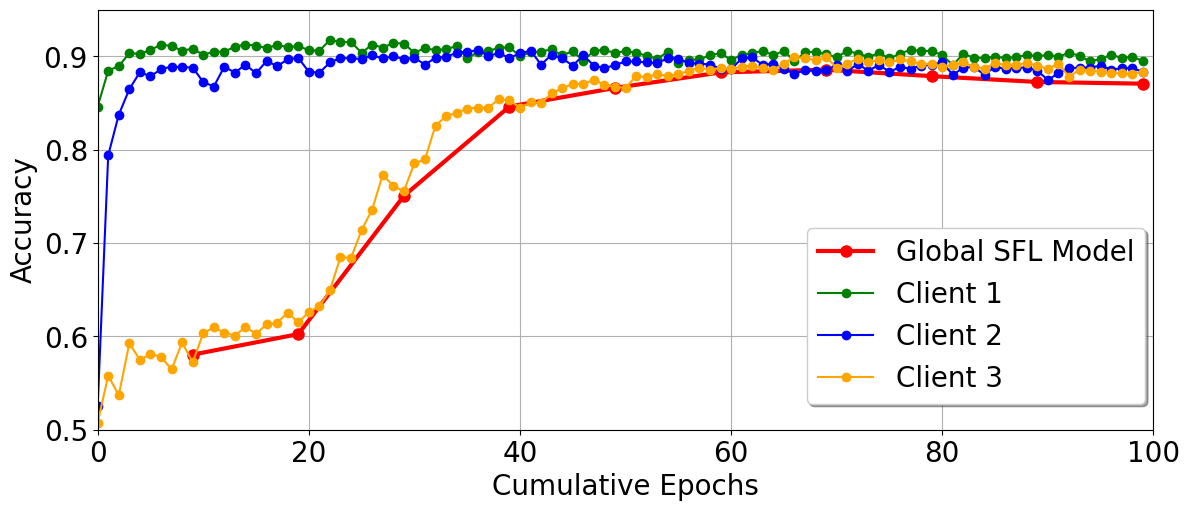

In [23]:
generate_single_plot_tikz_new_all(
    main_dir="/home/aladin/latest/resilient_sfl/logs/sc/multiruns/qnli_latest/qnli_roberta_per_batch_adversarial_bs32",
    dataset="qnli",
    model="roberta_for_sequence_classification",
    client_names=("client_0", "client_1", "client_2"),
    plot_name="singleplot.png"
)

In [28]:
def generate_single_plot_tikz_new_all_ner(main_dir: str, 
                              dataset: str, 
                              model: str, 
                              client_names=("client_0", "client_1", "client_2"),
                              plot_name="singleplot.png"):
    """
    Generate a single plot for all subfolders that match the given dataset and model.
    """
    # Define known scenarios and filter scenario
    known_scenarios = ["None", "no_jammer", "no_protection", "w_protection"]
    filter_scenario = "w_protection"

    # Fetch all relevant directories based on the dataset and model
    directories = fetch_relevant_directories(main_dir, dataset, model)

    # Create the main figure for the single plot
    fig, ax = plt.subplots(figsize=(12, 6))  # Adjusted to 6x6 inches

    for idx, directory in enumerate(directories):
        # Fetch the configuration for the current directory
        config = fetch_configuration(directory)

        # Handle relative paths
        relative_path_components = config.paths.client_log_path.split('/logs/', 1)[-1].split("/")
        relative_path = os.path.join(*relative_path_components[3:4])
        relative_path = os.path.join(relative_path, 'logs/')  
        config.paths.log_path = os.path.join(main_dir, relative_path)

        # Fetch the scenario from the config or tags.log
        scenario = None
        if "tags" in config:
            for tag in config.tags:
                if tag in known_scenarios:
                    scenario = tag
                    break

        if not scenario:
            with open(os.path.join(directory, "tags.log"), 'r') as file:
                content = file.read()
                tags = [tag.strip() for tag in content.strip("[]").split(",")]
                for tag in tags:
                    if tag in known_scenarios:
                        scenario = tag
                        break

        # Only plot for the filtered scenario
        if scenario != filter_scenario:
            continue

        for client_name in client_names:
            # Plot the metrics for the current directory on the single subplot axis
            client_train_df, client_val_df = accumulate_client_metrics(config, client_name + "_logger", config.paths.log_path)
            master_train_df, master_val_df = accumulate_master_metrics(config, config.paths.log_path)

            # Debug print statements to check data
            # print(f"Client: {client_name}")
            # print(client_val_df.head())
            # print(master_val_df.head())

            # Client mapping
            client_mapping = {
                "client_0": "Client 1",
                "client_1": "Client 2",
                "client_2": "Client 3",
            }
            color_mapping = {
                "client_0": "green",
                "client_1": "blue",
                "client_2": "orange",
                "Global SFL Model": "red"
            }

            # Apply client mapping to client_name
            display_name = client_mapping.get(client_name, client_name)
            color = color_mapping.get(client_name, "black")  # default to black if not found

            # Add plots to the single axis
            task = config.task_name
            if task == "sc":
                if client_name in client_mapping:
                    ax.plot(client_val_df['epoch'].to_numpy(), client_val_df['val_acc'].to_numpy(), label=f'{display_name}', linestyle='-', marker='o', color=color)
                if client_name == "client_0":
                    ax.plot(master_val_df['epoch'].to_numpy(), master_val_df['test_acc'].to_numpy(), label=f'Global SFL Model', linestyle='-', marker='o', linewidth=3, color=color_mapping["Global SFL Model"], markersize=8)
                ax.set_ylabel('Accuracy', fontsize=20)

            elif task == "ner":
                if client_name in client_mapping:
                    ax.plot(client_val_df['epoch'].to_numpy(), client_val_df['val_f1'].to_numpy(), label=f'{display_name}', linestyle='-', marker='o', color=color)
                if client_name == "client_0":
                    ax.plot(master_val_df['epoch'].to_numpy(), master_val_df['test_f1'].to_numpy(), label=f'Global SFL Model', linestyle='-', marker='o', linewidth=3, color=color_mapping["Global SFL Model"], markersize=8)
                ax.set_ylabel('F1 Score', fontsize=20)

    # Set labels for the single axis
    ax.set_ylim(0.2, 0.6)
    ax.set_xlim(0, 100)
    
    # Size adjustments
    ax.tick_params(axis='x', labelsize=20)
    ax.tick_params(axis='y', labelsize=20)

    ax.set_xlabel('Cumulative Epochs', fontsize=20) # Fontsize was 16
    ax.grid(True, alpha=1)
    
    # Add a single legend for the whole figure
    lines, labels = ax.get_legend_handles_labels()
    
    # Reorder the legend items as desired
    order = ["Global SFL Model", "Client 1", "Client 2", "Client 3"]
    ordered_lines_labels = sorted(zip(lines, labels), key=lambda x: order.index(x[1]))
    ordered_lines, ordered_labels = zip(*ordered_lines_labels)

    fig.legend(ordered_lines, ordered_labels, loc='lower right', fancybox=True, shadow=True, ncol=1, fontsize=20, bbox_to_anchor=(0.97, 0.17))
    # Adjust layout
    plt.tight_layout()
    plt.subplots_adjust(bottom=0.15, top=0.85)

    # Save the single plot
    tikz_save_path = os.path.join(main_dir, "singleplot.tex")
    tikzplotlib.save(tikz_save_path)
    print(tikz_save_path)
    save_fig(fig, save_path=os.path.join(main_dir, plot_name), latex=True, pdf=True)


/home/aladin/latest/resilient_sfl/logs/ner/multiruns/wnut_latest/wnut_roberta_per_batch_adversarial_bs4/singleplot.tex


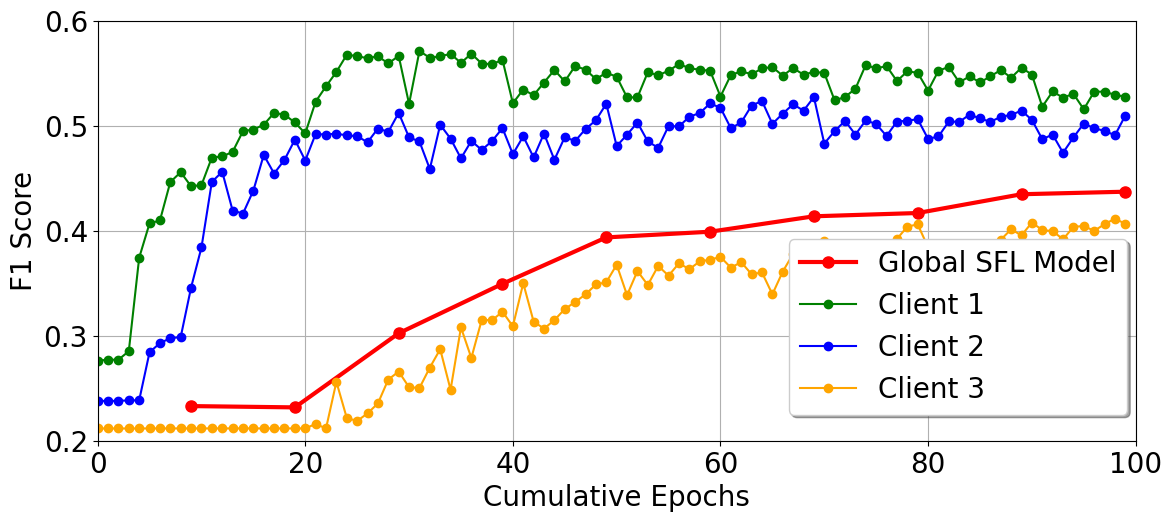

In [29]:
generate_single_plot_tikz_new_all_ner(
    main_dir="/home/aladin/latest/resilient_sfl/logs/ner/multiruns/wnut_latest/wnut_roberta_per_batch_adversarial_bs4",
    dataset="wnut",
    model="roberta_for_token_classification",
    client_names=("client_0", "client_1", "client_2"),
    plot_name="singleplot.png"
)

In [30]:
import matplotlib.pyplot as plt
import os
import tikzplotlib

def generate_single_plot_tikz_new_all_barrage(main_dir: str, 
                              dataset: str, 
                              model: str, 
                              client_names=("client_0", "client_1", "client_2"),
                              plot_name="singleplot.png"):
    """
    Generate a single plot for all subfolders that match the given dataset and model.
    """
    # Define known scenarios and filter scenario
    known_scenarios = ["None", "no_jammer", "no_protection", "w_protection"]
    filter_scenario = "w_protection"

    # Fetch all relevant directories based on the dataset and model
    directories = fetch_relevant_directories(main_dir, dataset, model)

    # Create the main figure for the single plot
    fig, ax = plt.subplots(figsize=(12, 6))  # Adjusted to 6x6 inches

    for idx, directory in enumerate(directories):
        # Fetch the configuration for the current directory
        config = fetch_configuration(directory)

        # Handle relative paths
        relative_path_components = config.paths.client_log_path.split('/logs/', 1)[-1].split("/")
        relative_path = os.path.join(*relative_path_components[3:4])
        relative_path = os.path.join(relative_path, 'logs/')  
        config.paths.log_path = os.path.join(main_dir, relative_path)

        # Fetch the scenario from the config or tags.log
        scenario = None
        if "tags" in config:
            for tag in config.tags:
                if tag in known_scenarios:
                    scenario = tag
                    break

        if not scenario:
            with open(os.path.join(directory, "tags.log"), 'r') as file:
                content = file.read()
                tags = [tag.strip() for tag in content.strip("[]").split(",")]
                for tag in tags:
                    if tag in known_scenarios:
                        scenario = tag
                        break

        # Only plot for the filtered scenario
        if scenario != filter_scenario:
            continue

        # Plot the global model metrics for the current directory on the single subplot axis
        master_train_df, master_val_df = accumulate_master_metrics(config, config.paths.log_path)

        color_mapping = {
            "Global SFL Model": "red"
        }

        # Add global model plots to the single axis
        task = config.task_name
        if task == "sc":
            ax.plot(master_val_df['epoch'].to_numpy(), master_val_df['test_acc'].to_numpy(), label='Global SFL Model', linestyle='-', marker='o', linewidth=3, color=color_mapping["Global SFL Model"], markersize=8)
            ax.set_ylabel('Accuracy', fontsize=16)

        elif task == "ner":
            ax.plot(master_val_df['epoch'].to_numpy(), master_val_df['test_f1'].to_numpy(), label='Global SFL Model', linestyle='-', marker='o', linewidth=3, color=color_mapping["Global SFL Model"], markersize=8)
            ax.set_ylabel('F1 Score', fontsize=16)

    # Set labels for the single axis
    ax.set_ylim(0.4, 1)
    ax.set_xlim(0, 100)
    
    # Size adjustments
    ax.tick_params(axis='x', labelsize=16)
    ax.tick_params(axis='y', labelsize=16)

    ax.set_xlabel('Cumulative Epochs', fontsize=16)
    ax.grid(True, alpha=1)
    
    # Add a single legend for the whole figure
    lines, labels = ax.get_legend_handles_labels()
    
    # Reorder the legend items as desired
    order = ["Global SFL Model"]
    ordered_lines_labels = sorted(zip(lines, labels), key=lambda x: order.index(x[1]))
    ordered_lines, ordered_labels = zip(*ordered_lines_labels)

    fig.legend(ordered_lines, ordered_labels, loc='lower right', fancybox=True, shadow=True, ncol=1, fontsize=12, bbox_to_anchor=(0.97, 0.17))
    # Adjust layout
    plt.tight_layout()
    plt.subplots_adjust(bottom=0.15, top=0.85)

    # Save the single plot
    tikz_save_path = os.path.join(main_dir, "singleplot.tex")
    tikzplotlib.save(tikz_save_path)
    print(tikz_save_path)
    save_fig(fig, save_path=os.path.join(main_dir, plot_name), latex=True, pdf=True)


In [31]:
def generate_single_plot_tikz_new_all_barrage(main_dir: str, 
                              dataset: str, 
                              model: str, 
                              client_names=("client_0", "client_1", "client_2"),
                              plot_name="singleplot.png"):
    """
    Generate a single plot for all subfolders that match the given dataset and model.
    """
    # Define known scenarios and their display names
    scenario_display_names = {
        "None": "SFL Baseline",
        "no_jammer": "Gaussian",
        "no_protection": "No Protection",
        "w_protection": "Protection"
    }

    # Fetch all relevant directories based on the dataset and model
    directories = fetch_relevant_directories(main_dir, dataset, model)

    # Create the main figure for the single plot
    fig, ax = plt.subplots(figsize=(12, 6))  # Adjusted to 6x6 inches

    colors = ['blue', 'orange', 'red', 'green']  # Different colors for different scenarios

    for idx, directory in enumerate(directories):
        # Fetch the configuration for the current directory
        config = fetch_configuration(directory)

        # Handle relative paths
        relative_path_components = config.paths.client_log_path.split('/logs/', 1)[-1].split("/")
        relative_path = os.path.join(*relative_path_components[3:4])
        relative_path = os.path.join(relative_path, 'logs/')  
        config.paths.log_path = os.path.join(main_dir, relative_path)

        # Fetch the scenario from the config or tags.log
        scenario = None
        if "tags" in config:
            for tag in config.tags:
                if tag in scenario_display_names:
                    scenario = tag
                    break

        if not scenario:
            with open(os.path.join(directory, "tags.log"), 'r') as file:
                content = file.read()
                tags = [tag.strip() for tag in content.strip("[]").split(",")]
                for tag in tags:
                    if tag in scenario_display_names:
                        scenario = tag
                        break

        if scenario is None:
            continue

        # Plot the global model metrics for the current directory on the single subplot axis
        master_train_df, master_val_df = accumulate_master_metrics(config, config.paths.log_path)

        color = colors[idx % len(colors)]

        # Add global model plots to the single axis
        task = config.task_name
        if task == "sc":
            ax.plot(master_val_df['epoch'].to_numpy(), master_val_df['test_acc'].to_numpy(), label=f'{scenario_display_names[scenario]}', linestyle='-', marker='o', linewidth=3, color=color, markersize=8)
            ax.set_ylabel('Accuracy', fontsize=16)
        elif task == "ner":
            ax.plot(master_val_df['epoch'].to_numpy(), master_val_df['test_f1'].to_numpy(), label=f'{scenario_display_names[scenario]}', linestyle='-', marker='o', linewidth=3, color=color, markersize=8)
            ax.set_ylabel('F1 Score', fontsize=16)

    # Set labels for the single axis
    ax.set_ylim(0.4, 1)
    ax.set_xlim(0, 100)
    
    # Size adjustments
    ax.tick_params(axis='x', labelsize=16)
    ax.tick_params(axis='y', labelsize=16)

    ax.set_xlabel('Cumulative Epochs', fontsize=16)
    ax.grid(True, alpha=1)
    
    # Add a single legend for the whole figure
    lines, labels = ax.get_legend_handles_labels()
    
    fig.legend(lines, labels, loc='lower right', fancybox=True, shadow=True, ncol=1, fontsize=12, bbox_to_anchor=(0.97, 0.17))
    
    # Adjust layout
    plt.tight_layout()
    plt.subplots_adjust(bottom=0.25, top=0.85)

    # Save the single plot
    tikz_save_path = os.path.join(main_dir, "singleplot.tex")
    tikzplotlib.save(tikz_save_path)
    print(tikz_save_path)
    save_fig(fig, save_path=os.path.join(main_dir, plot_name), latex=True, pdf=True)

/home/aladin/latest/resilient_sfl/logs/sc/multiruns/sst2_latest/sst2_bert_per_batch_adversarial_bs64/singleplot.tex


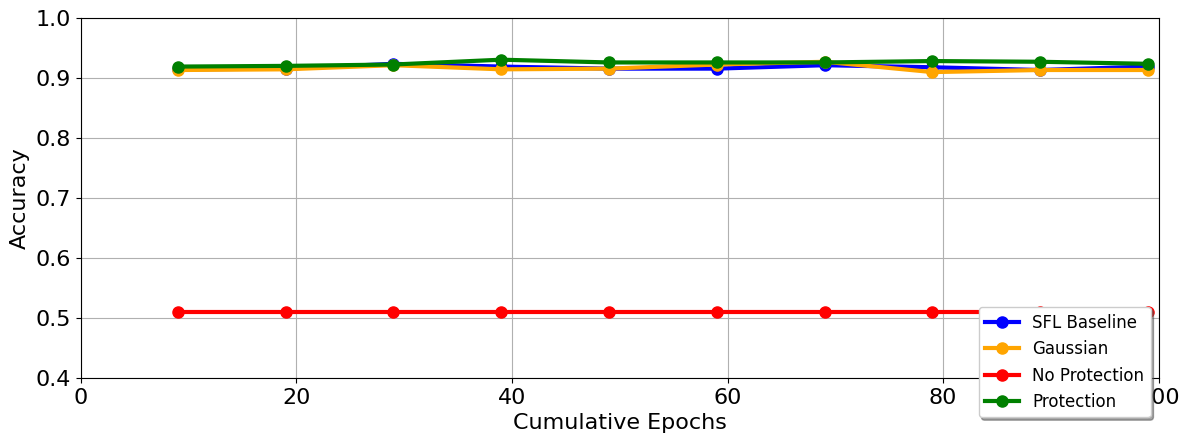

In [56]:
generate_single_plot_tikz_new_all_barrage(
    main_dir="/home/aladin/latest/resilient_sfl/logs/sc/multiruns/sst2_latest/sst2_bert_per_batch_adversarial_bs64",
    dataset="sst2",
    model="bert_for_sequence_classification",
    plot_name="singleplot.png"
)

Barrage directories found: ['/home/aladin/latest/resilient_sfl/logs/sc/multiruns/sst2_latest/sst2_roberta_per_round_adversarial_bs64/0', '/home/aladin/latest/resilient_sfl/logs/sc/multiruns/sst2_latest/sst2_roberta_per_round_adversarial_bs64/1', '/home/aladin/latest/resilient_sfl/logs/sc/multiruns/sst2_latest/sst2_roberta_per_round_adversarial_bs64/2', '/home/aladin/latest/resilient_sfl/logs/sc/multiruns/sst2_latest/sst2_roberta_per_round_adversarial_bs64/3']
Scenario for barrage directory: None
Scenario for barrage directory: None
Scenario for barrage directory: no_protection
Scenario for barrage directory: None
/home/aladin/latest/resilient_sfl/logs/sc/multiruns/sst2_latest/sst2_roberta_per_batch_adversarial_bs64/singleplot.tex


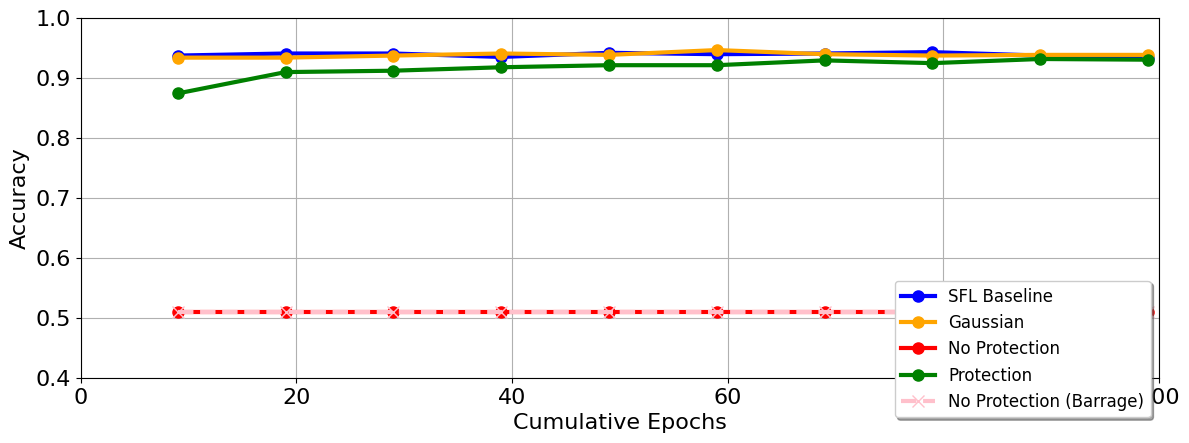

In [67]:
def generate_single_plot_tikz_new_all_barrage(main_dir: str, 
                              barrage_dir: str,
                              dataset: str, 
                              model: str, 
                              client_names=("client_0", "client_1", "client_2"),
                              plot_name="singleplot.png"):
    """
    Generate a single plot for all subfolders that match the given dataset and model.
    Additionally, include the global model from the "barrage" dataset for the "no protection" scenario in pink color.
    """
    # Define known scenarios and their display names
    scenario_display_names = {
        "None": "SFL Baseline",
        "no_jammer": "Gaussian",
        "no_protection": "No Protection",
        "w_protection": "Protection"
    }

    # Fetch all relevant directories based on the dataset and model
    directories = fetch_relevant_directories(main_dir, dataset, model)

    # Create the main figure for the single plot
    fig, ax = plt.subplots(figsize=(12, 6))  # Adjusted to 6x6 inches

    colors = ['blue', 'orange', 'red', 'green']  # Different colors for different scenarios

    for idx, directory in enumerate(directories):
        # Fetch the configuration for the current directory
        config = fetch_configuration(directory)

        # Handle relative paths
        relative_path_components = config.paths.client_log_path.split('/logs/', 1)[-1].split("/")
        relative_path = os.path.join(*relative_path_components[3:4])
        relative_path = os.path.join(relative_path, 'logs/')  
        config.paths.log_path = os.path.join(main_dir, relative_path)

        # Fetch the scenario from the config or tags.log
        scenario = None
        if "tags" in config:
            for tag in config.tags:
                if tag in scenario_display_names:
                    scenario = tag
                    break

        if not scenario:
            with open(os.path.join(directory, "tags.log"), 'r') as file:
                content = file.read()
                tags = [tag.strip() for tag in content.strip("[]").split(",")]
                for tag in tags:
                    if tag in scenario_display_names:
                        scenario = tag
                        break

        if scenario is None:
            continue

        # Plot the global model metrics for the current directory on the single subplot axis
        master_train_df, master_val_df = accumulate_master_metrics(config, config.paths.log_path)

        color = colors[idx % len(colors)]

        # Add global model plots to the single axis
        task = config.task_name
        if task == "sc":
            ax.plot(master_val_df['epoch'].to_numpy(), master_val_df['test_acc'].to_numpy(), label=f'{scenario_display_names[scenario]}', linestyle='-', marker='o', linewidth=3, color=color, markersize=8)
            ax.set_ylabel('Accuracy', fontsize=16)
        elif task == "ner":
            ax.plot(master_val_df['epoch'].to_numpy(), master_val_df['test_f1'].to_numpy(), label=f'{scenario_display_names[scenario]}', linestyle='-', marker='o', linewidth=3, color=color, markersize=8)
            ax.set_ylabel('F1 Score', fontsize=16)

    # Now include the barrage dataset for "no protection" scenario
    barrage_directories = fetch_relevant_directories(barrage_dir, dataset, model)
    print(f"Barrage directories found: {barrage_directories}")  # Debug statement

    for directory in barrage_directories:
        # Fetch the configuration for the current directory
        config = fetch_configuration(directory)

        # Handle relative paths
        relative_path_components = config.paths.client_log_path.split('/logs/', 1)[-1].split("/")
        relative_path = os.path.join(*relative_path_components[3:4])
        relative_path = os.path.join(relative_path, 'logs/')  
        config.paths.log_path = os.path.join(barrage_dir, relative_path)

        # Fetch the scenario from the config or tags.log
        scenario = None
        if "tags" in config:
            for tag in config.tags:
                if tag == "no_protection":
                    scenario = tag
                    break

        if not scenario:
            with open(os.path.join(directory, "tags.log"), 'r') as file:
                content = file.read()
                tags = [tag.strip() for tag in content.strip("[]").split(",")]
                for tag in tags:
                    if tag == "no_protection":
                        scenario = tag
                        break

        print(f"Scenario for barrage directory: {scenario}")  # Debug statement

        if scenario is None or scenario != "no_protection":
            continue

        # Plot the global model metrics for the current directory on the single subplot axis
        master_train_df, master_val_df = accumulate_master_metrics(config, config.paths.log_path)

        # Add global model plot for the "no protection" scenario in pink color
        task = config.task_name
        if task == "sc":
            ax.plot(master_val_df['epoch'].to_numpy(), master_val_df['test_acc'].to_numpy(), label='No Protection (Barrage)', linestyle='--', marker='x', linewidth=3, color='pink', markersize=8)
        elif task == "ner":
            ax.plot(master_val_df['epoch'].to_numpy(), master_val_df['test_f1'].to_numpy(), label='No Protection (Barrage)', linestyle='--', marker='x', linewidth=3, color='pink', markersize=8)

    # Set labels for the single axis
    ax.set_ylim(0.4, 1)
    ax.set_xlim(0, 100)
    
    # Size adjustments
    ax.tick_params(axis='x', labelsize=16)
    ax.tick_params(axis='y', labelsize=16)

    ax.set_xlabel('Cumulative Epochs', fontsize=16)
    ax.grid(True, alpha=1)
    
    # Add a single legend for the whole figure
    lines, labels = ax.get_legend_handles_labels()
    
    fig.legend(lines, labels, loc='lower right', fancybox=True, shadow=True, ncol=1, fontsize=12, bbox_to_anchor=(0.97, 0.17))
    
    # Adjust layout
    plt.tight_layout()
    plt.subplots_adjust(bottom=0.25, top=0.85)

    # Save the single plot
    tikz_save_path = os.path.join(main_dir, "singleplot.tex")
    tikzplotlib.save(tikz_save_path)
    print(tikz_save_path)
    save_fig(fig, save_path=os.path.join(main_dir, plot_name), latex=True, pdf=True)
    
# Example usage
generate_single_plot_tikz_new_all_barrage(
    main_dir="/home/aladin/latest/resilient_sfl/logs/sc/multiruns/sst2_latest/sst2_roberta_per_batch_adversarial_bs64",
    barrage_dir="/home/aladin/latest/resilient_sfl/logs/sc/multiruns/sst2_latest/sst2_roberta_per_round_adversarial_bs64",
    dataset="sst2",
    model="roberta_for_sequence_classification",
    plot_name="singleplot.png"
)


Barrage directories found: ['/home/aladin/latest/resilient_sfl/logs/ner/multiruns/2024-06-21_09-23-52/0', '/home/aladin/latest/resilient_sfl/logs/ner/multiruns/2024-06-21_09-23-52/1']
Scenario for barrage directory: no_protection
Scenario for barrage directory: w_protection
/home/aladin/latest/resilient_sfl/logs/ner/multiruns/conll_latest/conll_bert_per_batch_adversarial_bs16/singleplot.tex


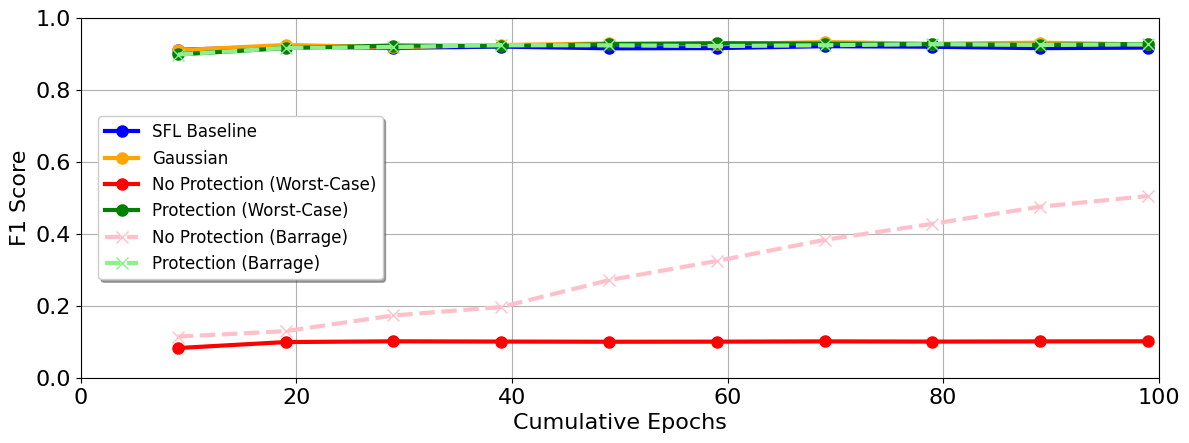

In [114]:
import matplotlib.pyplot as plt
import os
import tikzplotlib

def generate_single_plot_tikz_new_all_barrage(main_dir: str, 
                              barrage_dir: str,
                              dataset: str, 
                              model: str, 
                              client_names=("client_0", "client_1", "client_2"),
                              plot_name="singleplot.png"):
    """
    Generate a single plot for all subfolders that match the given dataset and model.
    Additionally, include the global model from the "barrage" dataset for the "no protection" and "w protection" scenarios.
    """
    # Define known scenarios and their display names
    scenario_display_names = {
        "None": "SFL Baseline",
        "no_jammer": "Gaussian",
        "no_protection": "No Protection (Worst-Case)",
        "w_protection": "Protection (Worst-Case)"
    }

    # Fetch all relevant directories based on the dataset and model
    directories = fetch_relevant_directories(main_dir, dataset, model)

    # Create the main figure for the single plot
    fig, ax = plt.subplots(figsize=(12, 6))  # Adjusted to 6x6 inches

    colors = ['blue', 'orange', 'red', 'green']  # Different colors for different scenarios

    for idx, directory in enumerate(directories):
        # Fetch the configuration for the current directory
        config = fetch_configuration(directory)

        # Handle relative paths
        relative_path_components = config.paths.client_log_path.split('/logs/', 1)[-1].split("/")
        relative_path = os.path.join(*relative_path_components[3:4])
        relative_path = os.path.join(relative_path, 'logs/')  
        config.paths.log_path = os.path.join(main_dir, relative_path)

        # Fetch the scenario from the config or tags.log
        scenario = None
        if "tags" in config:
            for tag in config.tags:
                if tag in scenario_display_names:
                    scenario = tag
                    break

        if not scenario:
            with open(os.path.join(directory, "tags.log"), 'r') as file:
                content = file.read()
                tags = [tag.strip() for tag in content.strip("[]").split(",")]
                for tag in tags:
                    if tag in scenario_display_names:
                        scenario = tag
                        break

        if scenario is None:
            continue

        # Plot the global model metrics for the current directory on the single subplot axis
        master_train_df, master_val_df = accumulate_master_metrics(config, config.paths.log_path)

        color = colors[idx % len(colors)]

        # Add global model plots to the single axis
        task = config.task_name
        if task == "sc":
            ax.plot(master_val_df['epoch'].to_numpy(), master_val_df['test_acc'].to_numpy(), label=f'{scenario_display_names[scenario]}', linestyle='-', marker='o', linewidth=3, color=color, markersize=8)
            ax.set_ylabel('Accuracy', fontsize=16)
        elif task == "ner":
            ax.plot(master_val_df['epoch'].to_numpy(), master_val_df['test_f1'].to_numpy(), label=f'{scenario_display_names[scenario]}', linestyle='-', marker='o', linewidth=3, color=color, markersize=8)
            ax.set_ylabel('F1 Score', fontsize=16)

    # Now include the barrage dataset for "no protection" and "w protection" scenarios
    barrage_directories = fetch_relevant_directories(barrage_dir, dataset, model)
    print(f"Barrage directories found: {barrage_directories}")  # Debug statement

    for directory in barrage_directories:
        # Fetch the configuration for the current directory
        config = fetch_configuration(directory)

        # Handle relative paths
        relative_path_components = config.paths.client_log_path.split('/logs/', 1)[-1].split("/")
        relative_path = os.path.join(*relative_path_components[3:4])
        relative_path = os.path.join(relative_path, 'logs/')  
        config.paths.log_path = os.path.join(barrage_dir, relative_path)

        # Fetch the scenario from the config or tags.log
        scenario = None
        if "tags" in config:
            for tag in config.tags:
                if tag == "no_protection" or tag == "w_protection":
                    scenario = tag
                    break

        if not scenario:
            with open(os.path.join(directory, "tags.log"), 'r') as file:
                content = file.read()
                tags = [tag.strip() for tag in content.strip("[]").split(",")]
                for tag in tags:
                    if tag == "no_protection" or tag == "w_protection":
                        scenario = tag
                        break

        print(f"Scenario for barrage directory: {scenario}")  # Debug statement

        if scenario is None:
            continue

        # Plot the global model metrics for the current directory on the single subplot axis
        master_train_df, master_val_df = accumulate_master_metrics(config, config.paths.log_path)

        # Add global model plot for the "no protection" scenario in pink color
        task = config.task_name
        if scenario == "no_protection":
            if task == "sc":
                ax.plot(master_val_df['epoch'].to_numpy(), master_val_df['test_acc'].to_numpy(), label='No Protection (Barrage)', linestyle='--', marker='x', linewidth=3, color='pink', markersize=8)
            elif task == "ner":
                ax.plot(master_val_df['epoch'].to_numpy(), master_val_df['test_f1'].to_numpy(), label='No Protection (Barrage)', linestyle='--', marker='x', linewidth=3, color='pink', markersize=8)
        elif scenario == "w_protection":
            if task == "sc":
                ax.plot(master_val_df['epoch'].to_numpy(), master_val_df['test_acc'].to_numpy(), label='Protection (Barrage)', linestyle='--', marker='x', linewidth=3, color='#90EE90', markersize=8)
            elif task == "ner":
                ax.plot(master_val_df['epoch'].to_numpy(), master_val_df['test_f1'].to_numpy(), label='Protection (Barrage)', linestyle='--', marker='x', linewidth=3, color='#90EE90', markersize=8)

    # Set labels for the single axis
    ax.set_ylim(0, 1)
    ax.set_xlim(0, 100)
    
    # Size adjustments
    ax.tick_params(axis='x', labelsize=16)
    ax.tick_params(axis='y', labelsize=16)

    ax.set_xlabel('Cumulative Epochs', fontsize=16)
    ax.grid(True, alpha=1)
    
    # Add a single legend for the whole figure
    lines, labels = ax.get_legend_handles_labels()
    
    # fig.legend(lines, labels, loc='lower right', fancybox=True, shadow=True, ncol=1, fontsize=12, bbox_to_anchor=(0.97, 0.17))
    
    # RoBERTa Legend
    # fig.legend(lines, labels, loc='lower right', fancybox=True, shadow=True, ncol=1, fontsize=12, bbox_to_anchor=(0.97, 0.4))

    # BERT LEGEND
    fig.legend(lines, labels, loc='lower right', fancybox=True, shadow=True, ncol=1, fontsize=12, bbox_to_anchor=(0.33, 0.4))


    # Adjust layout
    plt.tight_layout()
    plt.subplots_adjust(bottom=0.25, top=0.85)

    # Save the single plot
    tikz_save_path = os.path.join(main_dir, "singleplot.tex")
    tikzplotlib.save(tikz_save_path)
    print(tikz_save_path)
    save_fig(fig, save_path=os.path.join(main_dir, plot_name), latex=True, pdf=True)
    
# # RoBERTa
# generate_single_plot_tikz_new_all_barrage(
#     main_dir="/home/aladin/latest/resilient_sfl/logs/ner/multiruns/conll_latest/conll_roberta_per_batch_adversarial_bs16",
#     barrage_dir="/home/aladin/latest/resilient_sfl/logs/ner/multiruns/2024-06-20_22-09-19",
#     dataset="conll",
#     model="roberta_for_token_classification",
#     plot_name="singleplot.png"
# )

# BERT
# generate_single_plot_tikz_new_all_barrage(
#     main_dir="/home/aladin/latest/resilient_sfl/logs/sc/multiruns/sst2_latest/sst2_bert_per_batch_adversarial_bs64",
#     barrage_dir="/home/aladin/latest/resilient_sfl/logs/sc/multiruns/2024-06-20_22-08-55",
#     dataset="sst2",
#     model="bert_for_sequence_classification",
#     plot_name="singleplot.png"
# )

# BERT CONLL2003
generate_single_plot_tikz_new_all_barrage(
    main_dir="/home/aladin/latest/resilient_sfl/logs/ner/multiruns/conll_latest/conll_bert_per_batch_adversarial_bs16",
    barrage_dir="/home/aladin/latest/resilient_sfl/logs/ner/multiruns/2024-06-21_09-23-52",
    dataset="conll",
    model="bert_for_token_classification",
    plot_name="singleplot.png"
)


In [90]:
# Load the MSE data
import numpy as np
mse_filepath = '/home/aladin/latest/resilient_sfl/mse_files/barrage_mses/'
all_mses_no_jammer = np.load(mse_filepath + 'mse_no_jammer.npy', allow_pickle=True)
all_mses_no_protection = np.load(mse_filepath + 'mse_no_protection.npy', allow_pickle=True)
all_mses_w_protection = np.load(mse_filepath + 'mse_w_protection.npy', allow_pickle=True)

# User collection
user1 = np.array([[a, b, c] for a, b, c in zip(all_mses_no_jammer[:300, 0], all_mses_no_protection[:300, 0], all_mses_w_protection[:300, 0])], dtype=np.float32)
user2 = np.array([[a, b, c] for a, b, c in zip(all_mses_no_jammer[:300, 1], all_mses_no_protection[:300, 1], all_mses_w_protection[:300, 1])], dtype=np.float32)
user3 = np.array([[a, b, c] for a, b, c in zip(all_mses_no_jammer[:300, 2], all_mses_no_protection[:300, 2], all_mses_w_protection[:300, 2])], dtype=np.float32)

# Compute mean value for user 1
print("USER 1 :")
user1_no_jammer = user1[:, 0]
user_1_no_jammer_mean = np.mean(user1_no_jammer)
user_1_no_jammer_mean = 10 * np.log10(user_1_no_jammer_mean)
print("No Jammer")
print(user_1_no_jammer_mean)

user1_no_protection = user1[:, 1]
user_1_no_protection_mean = np.mean(user1_no_protection)
user_1_no_protection_mean = 10 * np.log10(user_1_no_protection_mean)
print("No Protection")
print(user_1_no_protection_mean)

user1_w_protection = user1[:, 2]
user_1_w_protection_mean = np.mean(user1_w_protection)
user_1_w_protection_mean = 10 * np.log10(user_1_w_protection_mean)
print("Protection")
print(user_1_w_protection_mean)

print("-------------------------------")

# Compute mean value for user 2
print("USER 2 :")
user2_no_jammer = user2[:, 0]
user_2_no_jammer_mean = np.mean(user2_no_jammer)
user_2_no_jammer_mean = 10 * np.log10(user_2_no_jammer_mean)
print("No Jammer")
print(user_2_no_jammer_mean)

user2_no_protection = user2[:, 1]
user_2_no_protection_mean = np.mean(user2_no_protection)
user_2_no_protection_mean = 10 * np.log10(user_2_no_protection_mean)
print("No Protection")
print(user_2_no_protection_mean)

user2_w_protection = user2[:, 2]
user_2_w_protection_mean = np.mean(user2_w_protection)
user_2_w_protection_mean = 10 * np.log10(user_2_w_protection_mean)
print("Protection")
print(user_2_w_protection_mean)

print("-----------------------------")

# Compute mean value for user 3
print("USER 3 :")
user3_no_jammer = user3[:, 0]
user_3_no_jammer_mean = np.mean(user3_no_jammer)
user_3_no_jammer_mean = 10 * np.log10(user_3_no_jammer_mean)
print("No Jammer")
print(user_3_no_jammer_mean)

user3_no_protection = user3[:, 1]
user_3_no_protection_mean = np.mean(user3_no_protection)
user_3_no_protection_mean = 10 * np.log10(user_3_no_protection_mean)
print("No Protection")
print(user_3_no_protection_mean)

user3_w_protection = user3[:, 2]
user_3_w_protection_mean = np.mean(user3_w_protection)
user_3_w_protection_mean = 10 * np.log10(user_3_w_protection_mean)
print("Protection")
print(user_3_w_protection_mean)



USER 1 :
No Jammer
-10.402899980545044
No Protection
5.34359872341156
Protection
-8.223662376403809
-------------------------------
USER 2 :
No Jammer
-9.970911145210266
No Protection
8.009735345840454
Protection
-5.892541408538818
-----------------------------
USER 3 :
No Jammer
-10.832736492156982
No Protection
9.173482060432434
Protection
-3.4062105417251587


In [91]:
# Load the MSE data
import numpy as np
mse_filepath = '/home/aladin/latest/resilient_sfl/mse_files/mnli_mses/'
all_mses_no_jammer = np.load(mse_filepath + 'mse_no_jammer.npy', allow_pickle=True)
all_mses_no_protection = np.load(mse_filepath + 'mse_no_protection.npy', allow_pickle=True)
all_mses_w_protection = np.load(mse_filepath + 'mse_w_protection.npy', allow_pickle=True)

# User collection
user1 = np.array([[a, b, c] for a, b, c in zip(all_mses_no_jammer[:300, 0], all_mses_no_protection[:300, 0], all_mses_w_protection[:300, 0])], dtype=np.float32)
user2 = np.array([[a, b, c] for a, b, c in zip(all_mses_no_jammer[:300, 1], all_mses_no_protection[:300, 1], all_mses_w_protection[:300, 1])], dtype=np.float32)
user3 = np.array([[a, b, c] for a, b, c in zip(all_mses_no_jammer[:300, 2], all_mses_no_protection[:300, 2], all_mses_w_protection[:300, 2])], dtype=np.float32)

# Compute mean value for user 1
print("USER 1 :")
user1_no_jammer = user1[:, 0]
user_1_no_jammer_mean = np.mean(user1_no_jammer)
user_1_no_jammer_mean = 10 * np.log10(user_1_no_jammer_mean)
print("No Jammer")
print(user_1_no_jammer_mean)

user1_no_protection = user1[:, 1]
user_1_no_protection_mean = np.mean(user1_no_protection)
user_1_no_protection_mean = 10 * np.log10(user_1_no_protection_mean)
print("No Protection")
print(user_1_no_protection_mean)

user1_w_protection = user1[:, 2]
user_1_w_protection_mean = np.mean(user1_w_protection)
user_1_w_protection_mean = 10 * np.log10(user_1_w_protection_mean)
print("Protection")
print(user_1_w_protection_mean)

print("-------------------------------")

# Compute mean value for user 2
print("USER 2 :")
user2_no_jammer = user2[:, 0]
user_2_no_jammer_mean = np.mean(user2_no_jammer)
user_2_no_jammer_mean = 10 * np.log10(user_2_no_jammer_mean)
print("No Jammer")
print(user_2_no_jammer_mean)

user2_no_protection = user2[:, 1]
user_2_no_protection_mean = np.mean(user2_no_protection)
user_2_no_protection_mean = 10 * np.log10(user_2_no_protection_mean)
print("No Protection")
print(user_2_no_protection_mean)

user2_w_protection = user2[:, 2]
user_2_w_protection_mean = np.mean(user2_w_protection)
user_2_w_protection_mean = 10 * np.log10(user_2_w_protection_mean)
print("Protection")
print(user_2_w_protection_mean)

print("-----------------------------")

# Compute mean value for user 3
print("USER 3 :")
user3_no_jammer = user3[:, 0]
user_3_no_jammer_mean = np.mean(user3_no_jammer)
user_3_no_jammer_mean = 10 * np.log10(user_3_no_jammer_mean)
print("No Jammer")
print(user_3_no_jammer_mean)

user3_no_protection = user3[:, 1]
user_3_no_protection_mean = np.mean(user3_no_protection)
user_3_no_protection_mean = 10 * np.log10(user_3_no_protection_mean)
print("No Protection")
print(user_3_no_protection_mean)

user3_w_protection = user3[:, 2]
user_3_w_protection_mean = np.mean(user3_w_protection)
user_3_w_protection_mean = 10 * np.log10(user_3_w_protection_mean)
print("Protection")
print(user_3_w_protection_mean)



USER 1 :
No Jammer
-10.402899980545044
No Protection
23.290038108825684
Protection
-8.22365939617157
-------------------------------
USER 2 :
No Jammer
-9.970911145210266
No Protection
26.002936363220215
Protection
-5.892535448074341
-----------------------------
USER 3 :
No Jammer
-10.832736492156982
No Protection
27.19238042831421
Protection
-3.406197726726532


In [32]:
def generate_single_plot_tikz_OneJammer(main_dir: str, 
                              dataset: str, 
                              model: str, 
                              client_names=("client_0", "client_1", "client_2"),
                              plot_name="singleplot.png"):
    """
    Generate a single plot for all subfolders that match the given dataset and model.
    """
    # Define known scenarios and filter scenario
    known_scenarios = ["None", "no_jammer", "no_protection", "w_protection"]
    filter_scenario = "no_protection"

    # Fetch all relevant directories based on the dataset and model
    directories = fetch_relevant_directories(main_dir, dataset, model)

    # Create the main figure for the single plot
    fig, ax = plt.subplots(figsize=(12, 6))  # Adjusted to 6x6 inches

    for idx, directory in enumerate(directories):
        # Fetch the configuration for the current directory
        config = fetch_configuration(directory)

        # Handle relative paths
        relative_path_components = config.paths.client_log_path.split('/logs/', 1)[-1].split("/")
        relative_path = os.path.join(*relative_path_components[3:4])
        relative_path = os.path.join(relative_path, 'logs/')  
        config.paths.log_path = os.path.join(main_dir, relative_path)

        # Fetch the scenario from the config or tags.log
        scenario = None
        if "tags" in config:
            for tag in config.tags:
                if tag in known_scenarios:
                    scenario = tag
                    break

        if not scenario:
            with open(os.path.join(directory, "tags.log"), 'r') as file:
                content = file.read()
                tags = [tag.strip() for tag in content.strip("[]").split(",")]
                for tag in tags:
                    if tag in known_scenarios:
                        scenario = tag
                        break

        # Only plot for the filtered scenario
        if scenario != filter_scenario:
            continue

        for client_name in client_names:
            # Plot the metrics for the current directory on the single subplot axis
            client_train_df, client_val_df = accumulate_client_metrics(config, client_name + "_logger", config.paths.log_path)
            master_train_df, master_val_df = accumulate_master_metrics(config, config.paths.log_path)

            # Debug print statements to check data
            # print(f"Client: {client_name}")
            # print(client_val_df.head())
            # print(master_val_df.head())

            # Client mapping
            client_mapping = {
                "client_0": "Client 3",
                "client_1": "Client 2",
                "client_2": "Client 1",
            }
            color_mapping = {
                "client_0": "orange",
                "client_1": "blue",
                "client_2": "green",
                "Global SFL Model": "red"
            }

            # Apply client mapping to client_name
            display_name = client_mapping.get(client_name, client_name)
            color = color_mapping.get(client_name, "black")  # default to black if not found

            # Add plots to the single axis
            task = config.task_name
            if task == "sc":
                if client_name in client_mapping:
                    ax.plot(client_val_df['epoch'].to_numpy(), client_val_df['val_acc'].to_numpy(), label=f'{display_name}', linestyle='-', marker='o', color=color)
                if client_name == "client_0":
                    ax.plot(master_val_df['epoch'].to_numpy(), master_val_df['test_acc'].to_numpy(), label=f'Global SFL Model', linestyle='-', marker='o', linewidth=3, color=color_mapping["Global SFL Model"], markersize=8)
                ax.set_ylabel('Accuracy', fontsize=20)

            elif task == "ner":
                if client_name in client_mapping:
                    ax.plot(client_val_df['epoch'].to_numpy(), client_val_df['val_f1'].to_numpy(), label=f'{display_name}', linestyle='-', marker='o', color=color)
                if client_name == "client_0":
                    ax.plot(master_val_df['epoch'].to_numpy(), master_val_df['test_f1'].to_numpy(), label=f'Global SFL Model', linestyle='-', marker='o', linewidth=3, color=color_mapping["Global SFL Model"], markersize=8)
                ax.set_ylabel('F1 Score', fontsize=20)

    # Set labels for the single axis
    ax.set_ylim(0.4, 1)
    ax.set_xlim(0, 100)
    
    # Size adjustments
    ax.tick_params(axis='x', labelsize=20)
    ax.tick_params(axis='y', labelsize=20)

    ax.set_xlabel('Cumulative Epochs', fontsize=20)
    ax.grid(True, alpha=1)
    
    # Add a single legend for the whole figure
    lines, labels = ax.get_legend_handles_labels()
    
    # Reorder the legend items as desired
    order = ["Global SFL Model", "Client 1", "Client 2", "Client 3"]
    ordered_lines_labels = sorted(zip(lines, labels), key=lambda x: order.index(x[1]))
    ordered_lines, ordered_labels = zip(*ordered_lines_labels)

    fig.legend(ordered_lines, ordered_labels, loc='lower right', fancybox=True, shadow=True, ncol=1, fontsize=20, bbox_to_anchor=(0.95, 0.4))
    # Adjust layout
    plt.tight_layout()
    plt.subplots_adjust(bottom=0.15, top=0.85)

    # Save the single plot
    tikz_save_path = os.path.join(main_dir, "singleplot.tex")
    tikzplotlib.save(tikz_save_path)
    print(tikz_save_path)
    save_fig(fig, save_path=os.path.join(main_dir, plot_name), latex=True, pdf=True)

/home/aladin/latest/resilient_sfl/logs/sc/multiruns/2024-06-17_20-23-38/singleplot.tex


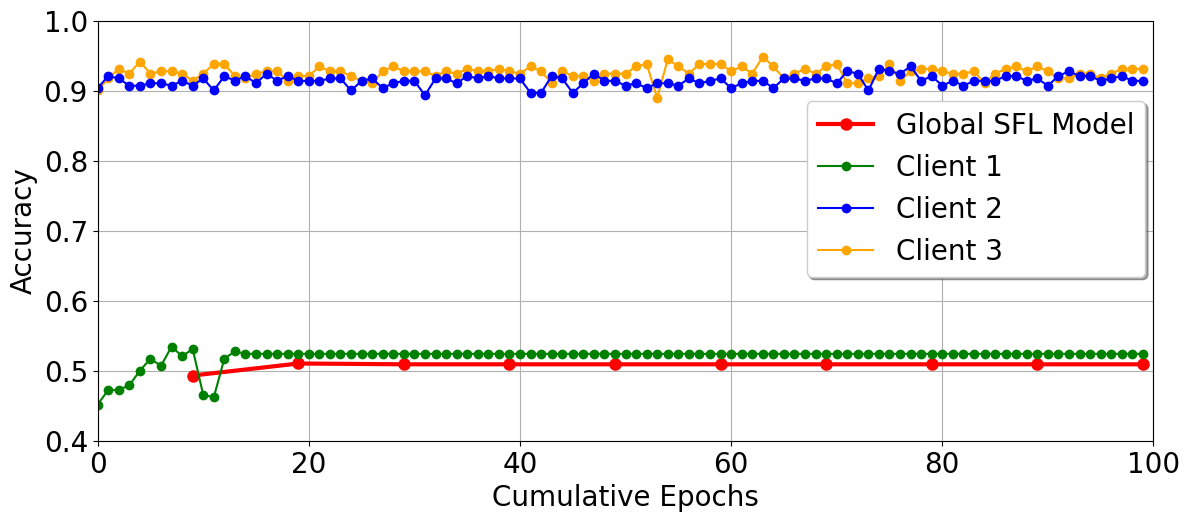

In [33]:
generate_single_plot_tikz_OneJammer(
    main_dir="/home/aladin/latest/resilient_sfl/logs/sc/multiruns/2024-06-17_20-23-38",
    dataset="sst2",
    model="bert_for_sequence_classification",
    client_names=("client_0", "client_1", "client_2"),
    plot_name="singleplot.png"
)

Jammer Stuff

/home/aladin/latest/resilient_sfl/logs/ner/multiruns/wnut_latest/wnut_roberta_per_batch_adversarial_bs4/doubleplot.tex


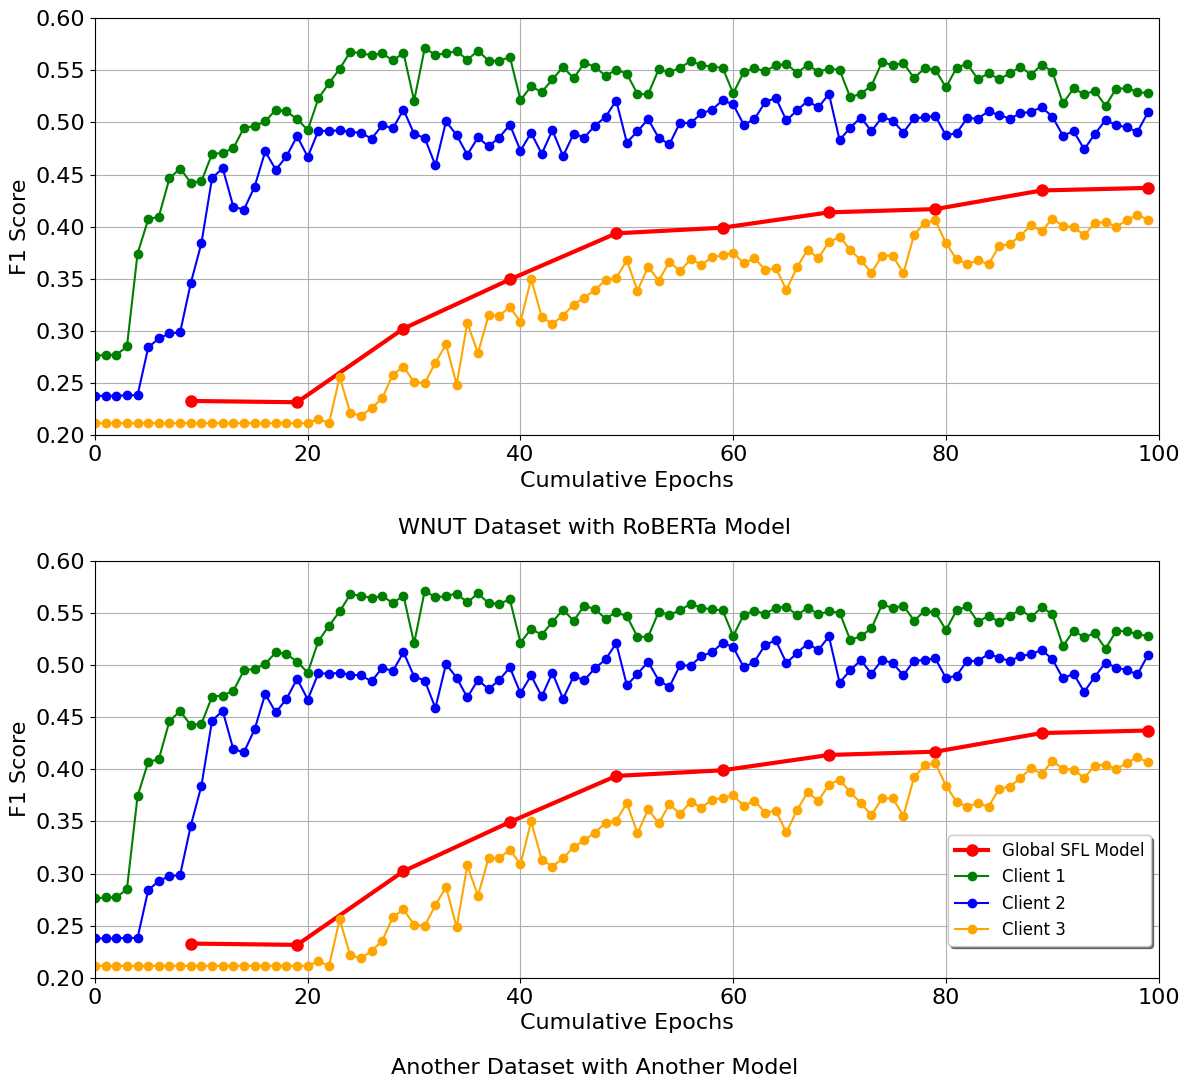

In [40]:
import matplotlib.pyplot as plt
import os
import tikzplotlib

def generate_double_plot_tikz_new_all_ner(main_dirs: list, 
                              datasets: list, 
                              models: list, 
                              captions: list,
                              client_names=("client_0", "client_1", "client_2"),
                              plot_name="doubleplot.png"):
    """
    Generate a 2x1 plot for all subfolders that match the given datasets and models.
    """
    # Define known scenarios and filter scenario
    known_scenarios = ["None", "no_jammer", "no_protection", "w_protection"]
    filter_scenario = "w_protection"

    # Create the main figure for the double plot
    fig, axs = plt.subplots(2, 1, figsize=(12, 12))  # Adjusted to 12x12 inches

    for i, (main_dir, dataset, model, caption) in enumerate(zip(main_dirs, datasets, models, captions)):
        # Fetch all relevant directories based on the dataset and model
        directories = fetch_relevant_directories(main_dir, dataset, model)

        for idx, directory in enumerate(directories):
            # Fetch the configuration for the current directory
            config = fetch_configuration(directory)

            # Handle relative paths
            relative_path_components = config.paths.client_log_path.split('/logs/', 1)[-1].split("/")
            relative_path = os.path.join(*relative_path_components[3:4])
            relative_path = os.path.join(relative_path, 'logs/')  
            config.paths.log_path = os.path.join(main_dir, relative_path)

            # Fetch the scenario from the config or tags.log
            scenario = None
            if "tags" in config:
                for tag in config.tags:
                    if tag in known_scenarios:
                        scenario = tag
                        break

            if not scenario:
                with open(os.path.join(directory, "tags.log"), 'r') as file:
                    content = file.read()
                    tags = [tag.strip() for tag in content.strip("[]").split(",")]
                    for tag in tags:
                        if tag in known_scenarios:
                            scenario = tag
                            break

            # Only plot for the filtered scenario
            if scenario != filter_scenario:
                continue

            for client_name in client_names:
                # Plot the metrics for the current directory on the single subplot axis
                client_train_df, client_val_df = accumulate_client_metrics(config, client_name + "_logger", config.paths.log_path)
                master_train_df, master_val_df = accumulate_master_metrics(config, config.paths.log_path)

                # Client mapping
                client_mapping = {
                    "client_0": "Client 1",
                    "client_1": "Client 2",
                    "client_2": "Client 3",
                }
                color_mapping = {
                    "client_0": "green",
                    "client_1": "blue",
                    "client_2": "orange",
                    "Global SFL Model": "red"
                }

                # Apply client mapping to client_name
                display_name = client_mapping.get(client_name, client_name)
                color = color_mapping.get(client_name, "black")  # default to black if not found

                # Add plots to the respective subplot axis
                ax = axs[i]
                task = config.task_name
                if task == "sc":
                    if client_name in client_mapping:
                        ax.plot(client_val_df['epoch'].to_numpy(), client_val_df['val_acc'].to_numpy(), label=f'{display_name}', linestyle='-', marker='o', color=color)
                    if client_name == "client_0":
                        ax.plot(master_val_df['epoch'].to_numpy(), master_val_df['test_acc'].to_numpy(), label=f'Global SFL Model', linestyle='-', marker='o', linewidth=3, color=color_mapping["Global SFL Model"], markersize=8)
                    ax.set_ylabel('Accuracy', fontsize=16)

                elif task == "ner":
                    if client_name in client_mapping:
                        ax.plot(client_val_df['epoch'].to_numpy(), client_val_df['val_f1'].to_numpy(), label=f'{display_name}', linestyle='-', marker='o', color=color)
                    if client_name == "client_0":
                        ax.plot(master_val_df['epoch'].to_numpy(), master_val_df['test_f1'].to_numpy(), label=f'Global SFL Model', linestyle='-', marker='o', linewidth=3, color=color_mapping["Global SFL Model"], markersize=8)
                    ax.set_ylabel('F1 Score', fontsize=16)

        # Set labels for the single axis
        ax.set_ylim(0.2, 0.6)
        ax.set_xlim(0, 100)
        
        # Size adjustments
        ax.tick_params(axis='x', labelsize=16)
        ax.tick_params(axis='y', labelsize=16)

        ax.set_xlabel('Cumulative Epochs', fontsize=16)
        ax.grid(True, alpha=1)
        
        # Add a single legend for the whole figure
        lines, labels = ax.get_legend_handles_labels()
        
        # Reorder the legend items as desired
        order = ["Global SFL Model", "Client 1", "Client 2", "Client 3"]
        ordered_lines_labels = sorted(zip(lines, labels), key=lambda x: order.index(x[1]))
        ordered_lines, ordered_labels = zip(*ordered_lines_labels)

        fig.legend(ordered_lines, ordered_labels, loc='lower right', fancybox=True, shadow=True, ncol=1, fontsize=12, bbox_to_anchor=(0.97, 0.17))
        
        # Add subplot caption
        fig.text(0.5, 0.52 if i == 0 else 0.07, caption, ha='center', fontsize=16)

    # Adjust layout
    plt.tight_layout()
    plt.subplots_adjust(bottom=0.15, top=0.95, hspace=0.3)

    # Save the double plot
    tikz_save_path = os.path.join(main_dirs[0], "doubleplot.tex")
    tikzplotlib.save(tikz_save_path)
    print(tikz_save_path)
    save_fig(fig, save_path=os.path.join(main_dirs[0], plot_name), latex=True, pdf=True)

# Example usage
main_dirs = [
    "/home/aladin/latest/resilient_sfl/logs/ner/multiruns/wnut_latest/wnut_roberta_per_batch_adversarial_bs4",
    "/home/aladin/latest/resilient_sfl/logs/ner/multiruns/wnut_latest/wnut_roberta_per_batch_adversarial_bs4"
]
datasets = ["wnut", "wnut"]
models = ["roberta_for_token_classification", "roberta_for_token_classification"]
captions = ["WNUT Dataset with RoBERTa Model", "Another Dataset with Another Model"]

generate_double_plot_tikz_new_all_ner(main_dirs, datasets, models, captions)


AttributeError: can't set attribute

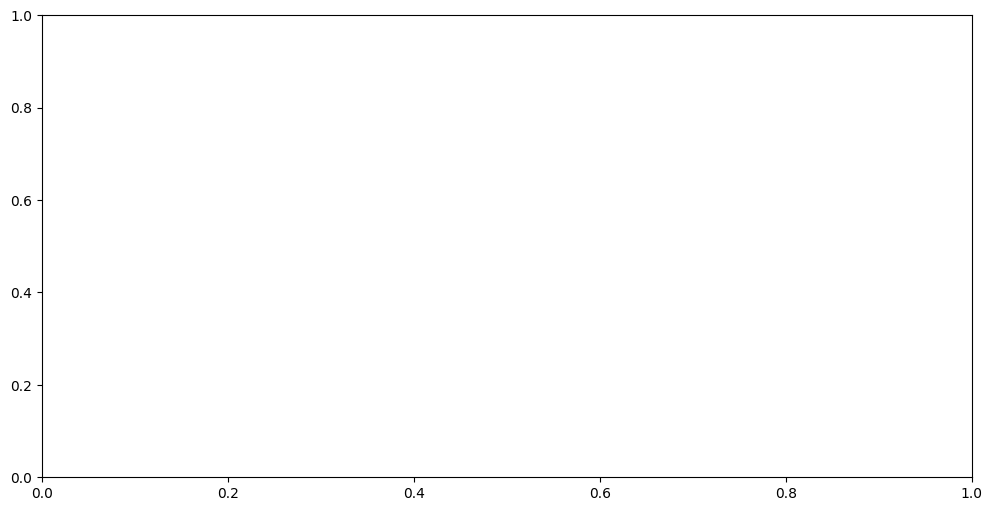

In [169]:
# Barrage Jammer 
def generate_single_plot_tikz_alt(main_dir: str, 
                                  dataset: str, 
                                  model: str, 
                                  plot_name="singleplot.png"):
    """
    Generate a single plot for all subfolders that match the given dataset and model.
    """
    # Define known scenarios
    known_scenarios = ["None", "no_jammer", "no_protection", "w_protection"]

    # Fetch all relevant directories based on the dataset and model
    directories = fetch_relevant_directories(main_dir, dataset, model)

    # Create the main figure for the single plot
    fig, ax = plt.subplots(figsize=(12, 6))

    for idx, directory in enumerate(directories):
        # Fetch the configuration for the current directory
        config = fetch_configuration(directory)

        # Handle relative paths
        relative_path_components = config.paths.client_log_path.split('/logs/', 1)[-1].split("/")
        relative_path = os.path.join(*relative_path_components[3:4])
        relative_path = os.path.join(relative_path, 'logs/')  
        config.paths.log_path = os.path.join(main_dir, relative_path)

        # Fetch the scenario from the config or tags.log
        scenario = None
        if "tags" in config:
            for tag in config.tags:
                if tag in known_scenarios:
                    scenario = tag
                    break

        if not scenario:
            with open(os.path.join(directory, "tags.log"), 'r') as file:
                content = file.read()
                tags = [tag.strip() for tag in content.strip("[]").split(",")]
                for tag in tags:
                    if tag in known_scenarios:
                        scenario = tag
                        break

        # Only plot for known scenarios
        if scenario not in known_scenarios:
            continue

        # Plot the metrics for the current directory on the single subplot axis
        master_train_df, master_val_df = accumulate_master_metrics(config, config.paths.log_path)

        # Add plots to the single axis
        task = config.task_name
        if task == "sc":
            ax.plot(master_val_df['epoch'].to_numpy(), master_val_df['test_acc'].to_numpy(), label=f'Global SFL Model ({scenario})', linestyle='-', marker='o', linewidth=3)
            ax.set_ylabel('Accuracy', fontsize=16)

        elif task == "ner":
            ax.plot(master_val_df['epoch'].to_numpy(), master_val_df['test_f1'].to_numpy(), label=f'Global SFL Model ({scenario})', linestyle='-', marker='o', linewidth=3)
            ax.set_ylabel('F1 Score', fontsize=16)

    # Set labels for the single axis
    ax.set_ylim(0.4, 1)
    ax.set_xlim(0, 100)
    
    # Size adjustments
    ax.tick_params(axis='x', labelsize=16)
    ax.tick_params(axis='y', labelsize=16)

    ax.set_xlabel('Cumulative Epochs', fontsize=16)
    ax.grid(True, alpha=1)
    
    # Add a single legend for the whole figure
    ax.legend(loc='lower right', fancybox=True, shadow=True, ncol=1, fontsize=12, bbox_to_anchor=(0.97, 0.4))
    # Adjust layout
    plt.tight_layout()
    plt.subplots_adjust(bottom=0.15, top=0.85)

    # Save the single plot
    tikz_save_path = os.path.join(main_dir, "singleplot.tex")
    tikzplotlib.save(tikz_save_path)
    print(tikz_save_path)
    save_fig(fig, save_path=os.path.join(main_dir, plot_name), latex=True, pdf=True)


generate_single_plot_tikz_alt(
    main_dir="/home/aladin/latest/resilient_sfl/logs/sc/multiruns/sst2_latest/sst2_bert_per_round_adversarial_bs64",
    dataset="sst2",
    model="bert_for_sequence_classification",
    plot_name="singleplot.png"
)

/home/aladin/latest/resilient_sfl/logs/sc/multiruns/sst2_latest/sst2_bert_per_round_adversarial_bs64/singleplot.tex


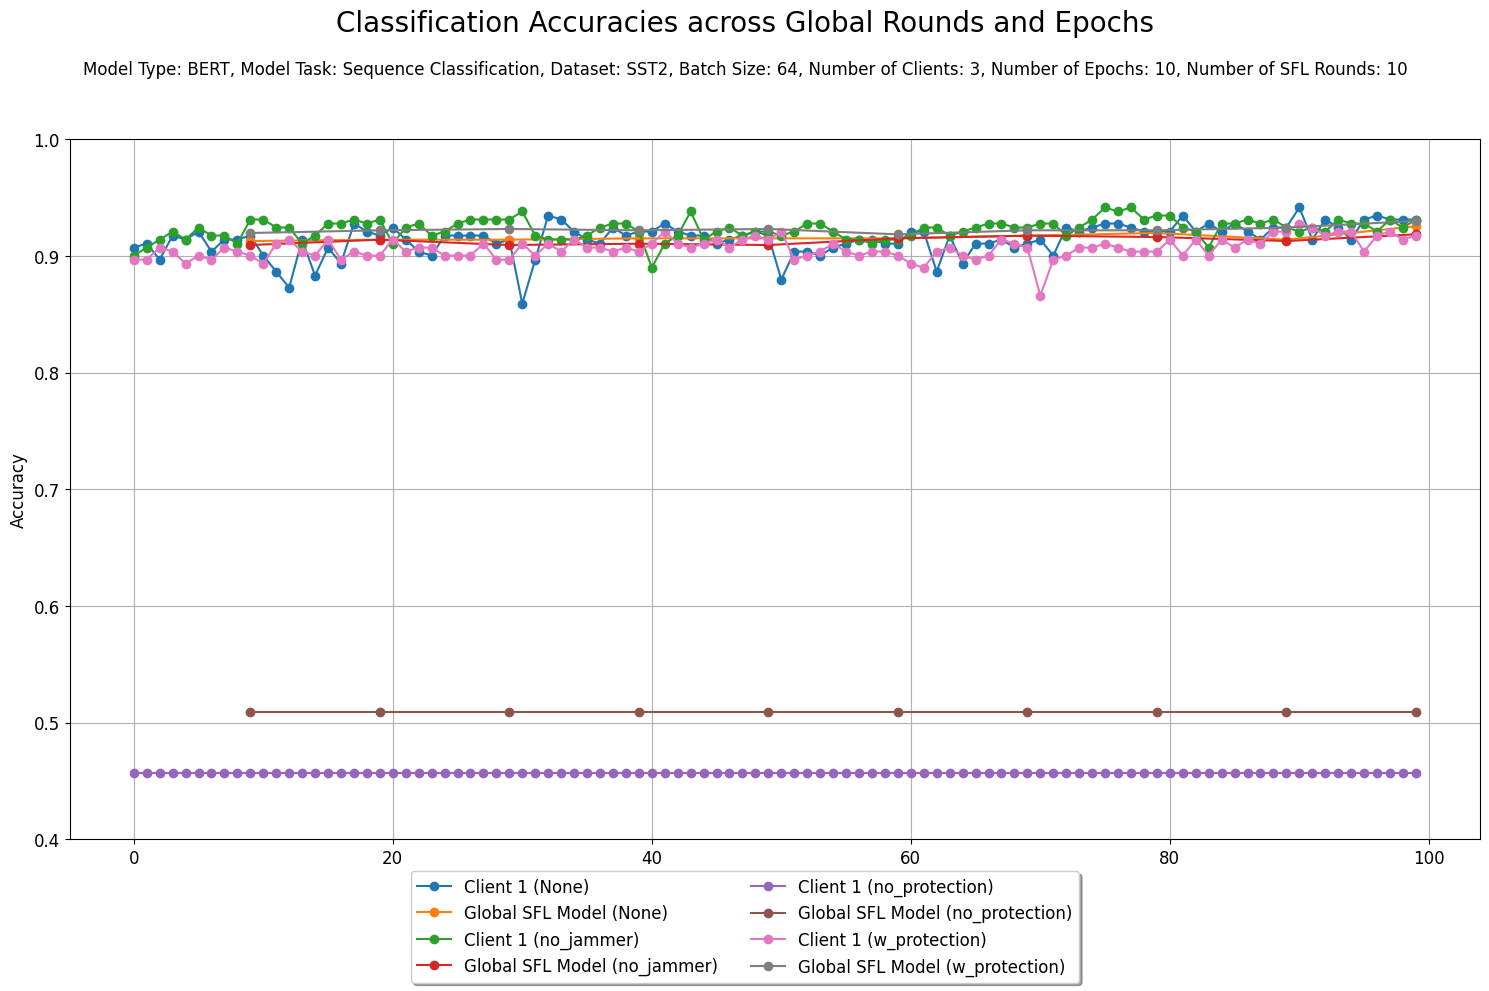

In [7]:
generate_single_plot_tikz(
    main_dir='/home/aladin/latest/resilient_sfl/logs/sc/multiruns/sst2_latest/sst2_bert_per_round_adversarial_bs64', 
    dataset='sst2', 
    model='bert_for_sequence_classification',
    client_name="client_0",
    plot_name="singleplot_sst2_bert.png")

In [ ]:
import numpy as np

In [12]:
# GET MSEs

mse_filepath = '/home/aladin/latest/resilient_sfl/mse_files/'
all_mses_no_jammer = np.load(mse_filepath + 'mse_no_jammer.npy', allow_pickle=True)
all_mses_no_protection = np.load(mse_filepath + 'mse_no_protection.npy', allow_pickle=True)
all_mses_w_protection = np.load(mse_filepath + 'mse_w_protection.npy', allow_pickle=True)

In [13]:
barrage_filepath = '/home/aladin/latest/resilient_sfl/barrage_no_protection.npy'
a = np.load(barrage_filepath, allow_pickle=True)

In [22]:
print(len(all_mses_no_protection))
print("------------------")
print(a[:10])

180000
------------------
[[3.29567832 7.67473089 7.36322814]
 [4.12551874 6.56002153 8.58964936]
 [3.35059766 7.63428152 7.46169867]
 [4.01439358 7.5538924  8.90511234]
 [3.68339081 5.98688449 7.88901603]
 [1.8463218  6.86359676 6.02436451]
 [4.12708328 5.69060461 7.74597672]
 [3.21479274 5.38863006 4.37082461]
 [3.45088407 8.35133901 7.61500479]
 [2.20906472 5.12838596 9.23531683]]


In [5]:
print(type(all_mses_no_jammer))

<class 'numpy.ndarray'>


In [13]:
def average_mse_per_user(mse_array, iterations, db=False):
    if iterations > mse_array.shape[0]:
        raise ValueError("Number of iterations exceeds the available data.")
    
    # Calculate the average for each user
    return np.mean(mse_array[:iterations, :], axis=0)

def average_sum_mse_all_users(mse_array, iterations):
    if iterations > mse_array.shape[0]:
        raise ValueError("Number of iterations exceeds the available data.")

    # Calculate the sum across users and then average
    return np.mean(np.sum(mse_array[:iterations, :], axis=1))

def mse_to_db(mse):
    return 10 * np.log10(mse)


In [24]:
mse_array = all_mses_no_protection
iterations = len(mse_array)

average_mse_per_user_result = average_mse_per_user(mse_array, iterations)
average_sum_mse_all_users_result = average_sum_mse_all_users(mse_array, iterations)

print("MSEs")
average_mse_per_user_result, average_sum_mse_all_users_result

print("MSEs in dB")
average_mse_per_user_result_db = mse_to_db(average_mse_per_user_result)
average_sum_mse_all_users_result_db = mse_to_db(average_sum_mse_all_users_result)
average_mse_per_user_result_db, average_sum_mse_all_users_result_db



MSEs
MSEs in dB


(array([23.27118756, 25.92674003, 27.13355729]), 30.49477739514665)

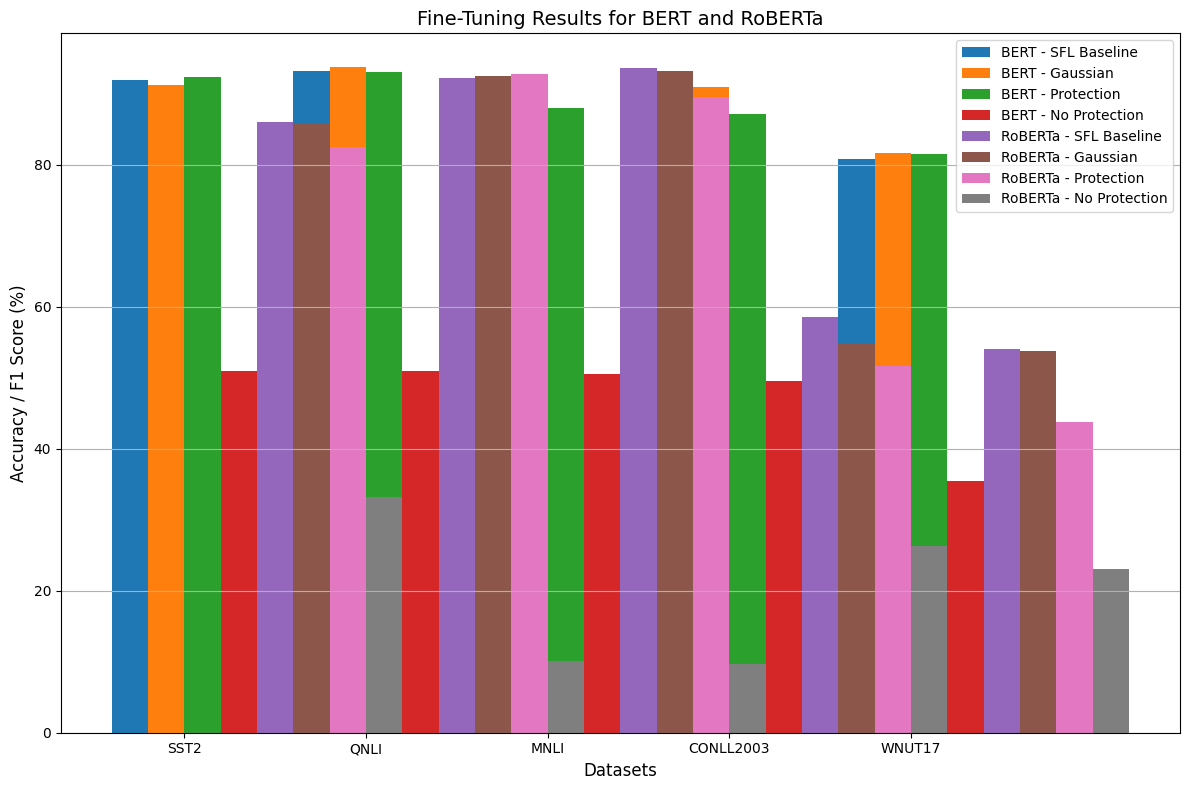

In [1]:
# Code for Plots

import matplotlib.pyplot as plt
import numpy as np

# Data
datasets = ["SST2", "QNLI", "MNLI", "CONLL2003", "WNUT17"]
models = ["BERT", "RoBERTa"]
scenarios = ["SFL Baseline", "Gaussian", "Protection", "No Protection"]

accuracy_data = [
    [91.9, 91.2, 92.3, 50.9],  # SST2 (BERT)
    [93.2, 93.8, 93.0, 50.9],  # SST2 (RoBERTa)
    [87.9, 87.8, 88.0, 50.5],  # QNLI (BERT)
    [91.5, 91.0, 87.1, 49.5],  # QNLI (RoBERTa)
    [80.8, 81.6, 81.5, 35.4],  # MNLI (BERT)
    [86.0, 85.7, 82.5, 33.2],  # MNLI (RoBERTa)
    [92.2, 92.5, 92.7, 10.1],  # CONLL2003 (BERT)
    [93.6, 93.2, 89.5, 9.7],   # CONLL2003 (RoBERTa)
    [58.5, 54.8, 51.7, 26.3],  # WNUT17 (BERT)
    [54.1, 53.8, 43.7, 23.1],  # WNUT17 (RoBERTa)
]

accuracy_data = np.array(accuracy_data)

# Plotting
fig, ax = plt.subplots(figsize=(12, 8))

# Define bar width
bar_width = 0.2
index = np.arange(len(datasets))

# Plotting bars for each scenario
for i, model in enumerate(models):
    for j, scenario in enumerate(scenarios):
        ax.bar(index + bar_width * j + i * (bar_width * len(scenarios)), 
               accuracy_data[i*len(datasets):(i+1)*len(datasets), j], 
               bar_width, label=f'{model} - {scenario}')

# Setting labels and titles
ax.set_xlabel('Datasets', fontsize=12)
ax.set_ylabel('Accuracy / F1 Score (%)', fontsize=12)
ax.set_title('Fine-Tuning Results for BERT and RoBERTa', fontsize=14)
ax.set_xticks(index + bar_width * (len(scenarios) - 1) / 2)
ax.set_xticklabels(datasets)
ax.legend()

plt.grid(axis='y')
plt.tight_layout()
plt.show()


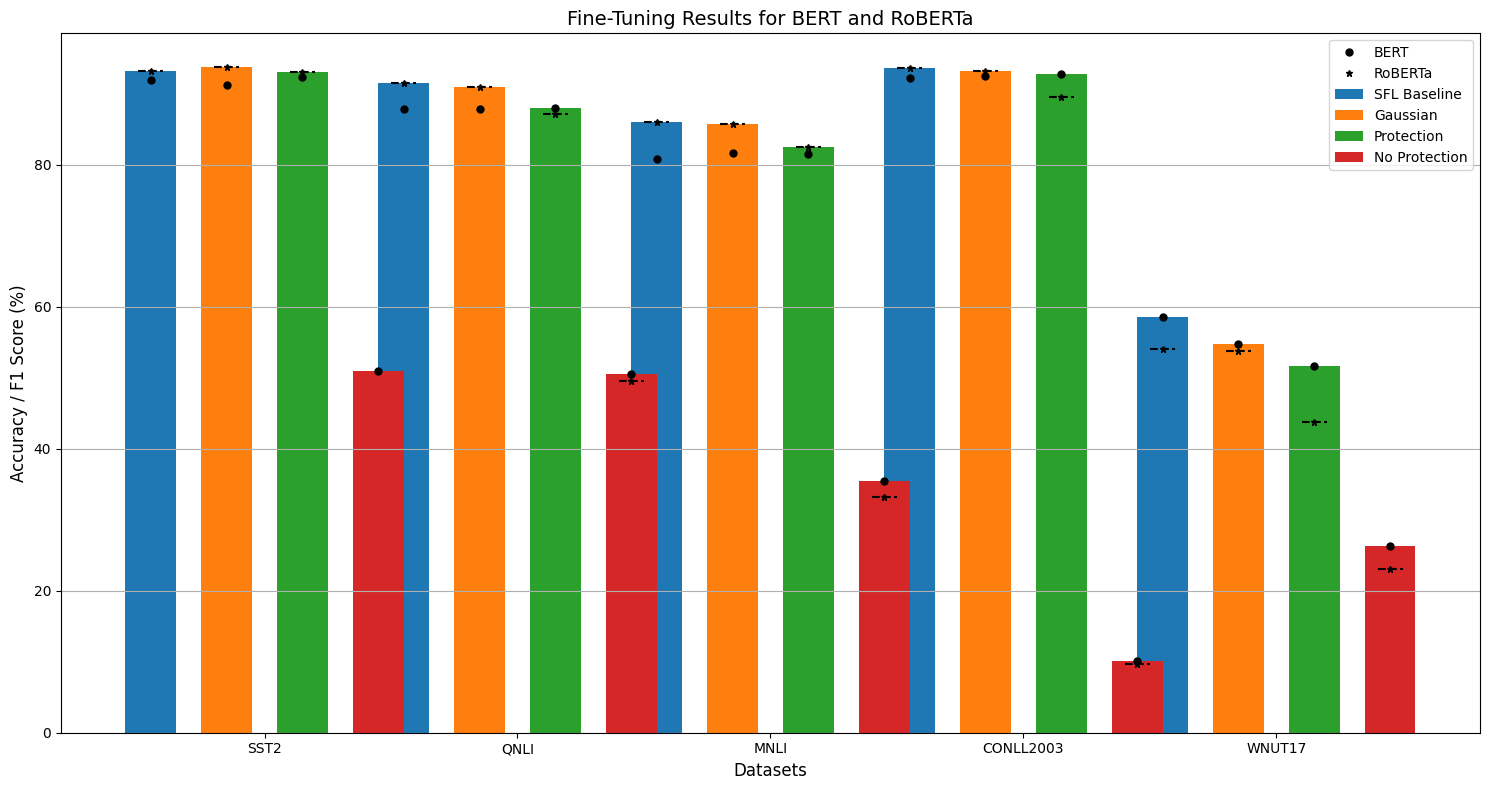

In [8]:
import matplotlib.pyplot as plt
import numpy as np

# Data
datasets = ["SST2", "QNLI", "MNLI", "CONLL2003", "WNUT17"]
scenarios = ["SFL Baseline", "Gaussian", "Protection", "No Protection"]

accuracy_data = [
    [91.9, 91.2, 92.3, 50.9],  # SST2 (BERT)
    [93.2, 93.8, 93.0, 50.9],  # SST2 (RoBERTa)
    [87.9, 87.8, 88.0, 50.5],  # QNLI (BERT)
    [91.5, 91.0, 87.1, 49.5],  # QNLI (RoBERTa)
    [80.8, 81.6, 81.5, 35.4],  # MNLI (BERT)
    [86.0, 85.7, 82.5, 33.2],  # MNLI (RoBERTa)
    [92.2, 92.5, 92.7, 10.1],  # CONLL2003 (BERT)
    [93.6, 93.2, 89.5, 9.7],   # CONLL2003 (RoBERTa)
    [58.5, 54.8, 51.7, 26.3],  # WNUT17 (BERT)
    [54.1, 53.8, 43.7, 23.1],  # WNUT17 (RoBERTa)
]

accuracy_data = np.array(accuracy_data)

# Plotting
fig, ax = plt.subplots(figsize=(15, 8))

# Define bar width and spacing
bar_width = 0.2
index = np.arange(len(datasets))
spacing = 0.1  # spacing between groups of bars

# Plotting bars for each scenario
for j, scenario in enumerate(scenarios):
    heights = []
    bert_markers = []
    roberta_markers = []
    for i in range(len(datasets)):
        bert_score = accuracy_data[2*i, j]
        roberta_score = accuracy_data[2*i+1, j]
        max_height = max(bert_score, roberta_score)
        heights.append(max_height)
        bert_markers.append(bert_score)
        roberta_markers.append(roberta_score)
    
    # Plot the main bar
    bar_positions = index + j * (bar_width + spacing)
    bars = ax.bar(bar_positions, heights, bar_width, label=scenario)

    # Add markers for BERT and RoBERTa
    for k in range(len(datasets)):
        ax.plot(bar_positions[k], bert_markers[k], 'ko', markersize=5, label="BERT" if j == 0 and k == 0 else "")
        ax.plot(bar_positions[k], roberta_markers[k], 'k*', markersize=5, label="RoBERTa" if j == 0 and k == 0 else "")
        if bert_markers[k] != roberta_markers[k]:
            ax.plot([bar_positions[k] - bar_width/4, bar_positions[k] + bar_width/4], 
                    [roberta_markers[k]] * 2, 'k--')

# Setting labels and titles
ax.set_xlabel('Datasets', fontsize=12)
ax.set_ylabel('Accuracy / F1 Score (%)', fontsize=12)
ax.set_title('Fine-Tuning Results for BERT and RoBERTa', fontsize=14)
ax.set_xticks(index + (len(scenarios) - 1) * (bar_width + spacing) / 2)
ax.set_xticklabels(datasets)
ax.legend()

# Add grid and layout adjustments
plt.grid(axis='y')
plt.tight_layout()
plt.show()


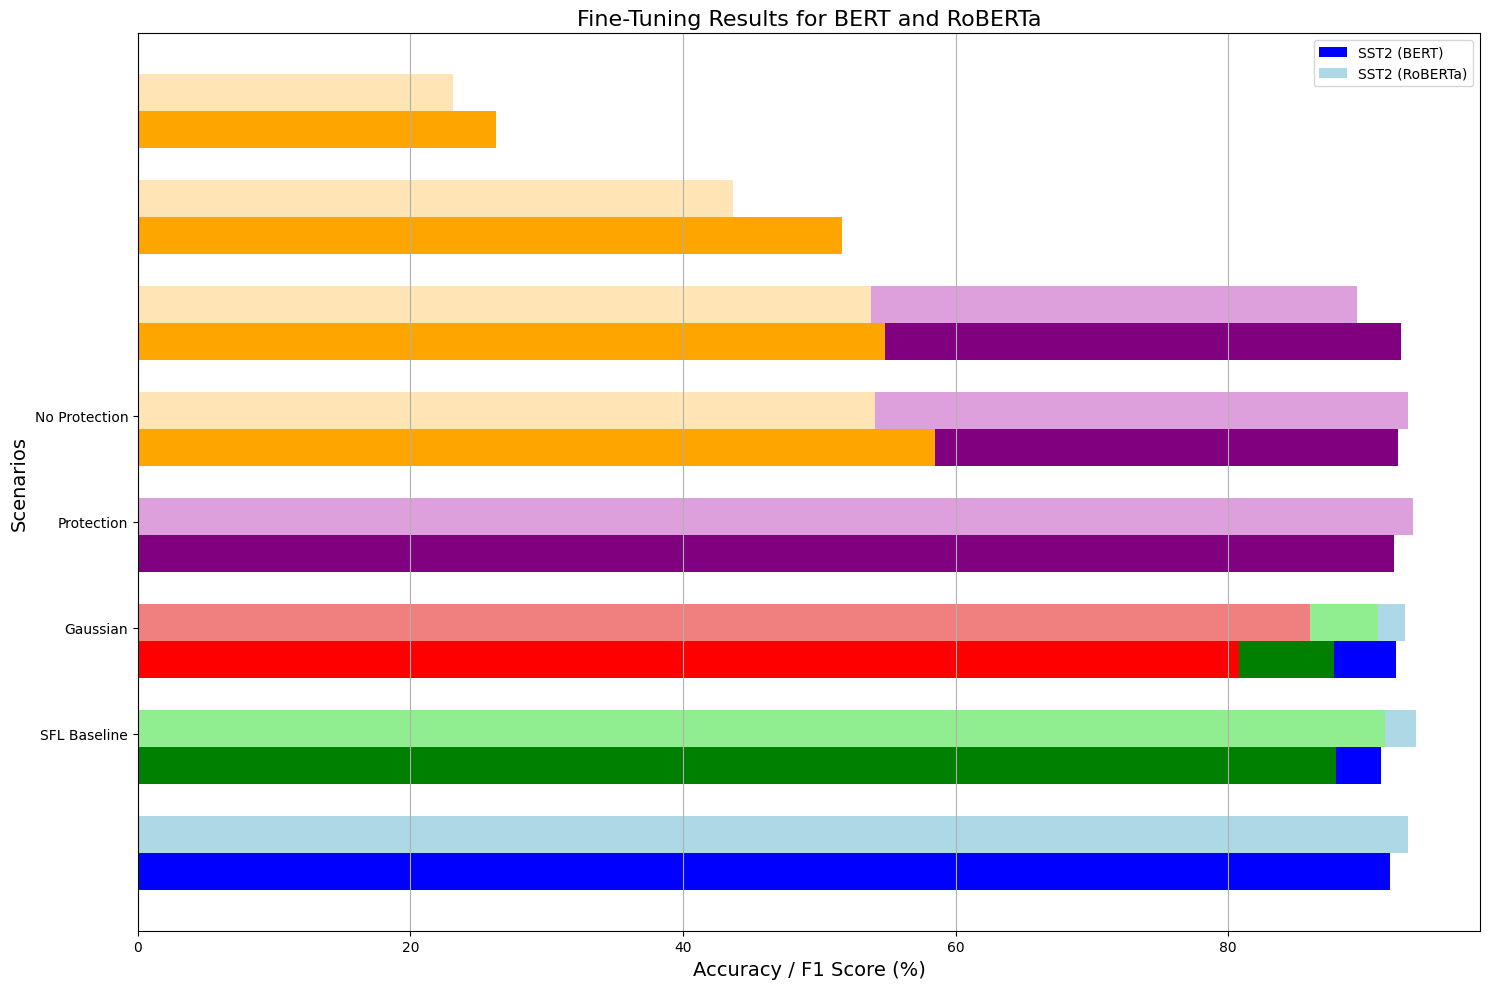

In [16]:
import matplotlib.pyplot as plt
import numpy as np

# Data
datasets = ["SST2", "QNLI", "MNLI", "CONLL2003", "WNUT17"]
scenarios = ["SFL Baseline", "Gaussian", "Protection", "No Protection"]

accuracy_data = [
    [91.9, 91.2, 92.3, 50.9],  # SST2 (BERT)
    [93.2, 93.8, 93.0, 50.9],  # SST2 (RoBERTa)
    [87.9, 87.8, 88.0, 50.5],  # QNLI (BERT)
    [91.5, 91.0, 87.1, 49.5],  # QNLI (RoBERTa)
    [80.8, 81.6, 81.5, 35.4],  # MNLI (BERT)
    [86.0, 85.7, 82.5, 33.2],  # MNLI (RoBERTa)
    [92.2, 92.5, 92.7, 10.1],  # CONLL2003 (BERT)
    [93.6, 93.2, 89.5, 9.7],   # CONLL2003 (RoBERTa)
    [58.5, 54.8, 51.7, 26.3],  # WNUT17 (BERT)
    [54.1, 53.8, 43.7, 23.1],  # WNUT17 (RoBERTa)
]

accuracy_data = np.array(accuracy_data)

# Define bar width and colors
bar_width = 0.35
colors = ['blue', 'green', 'red', 'purple', 'orange']
light_colors = ['lightblue', 'lightgreen', 'lightcoral', 'plum', 'moccasin']

# Plotting
fig, ax = plt.subplots(figsize=(15, 10))

for i, dataset in enumerate(datasets):
    y_positions = np.arange(len(scenarios)) + i * (bar_width * 2 + 0.3)
    bert_scores = accuracy_data[2*i:2*i+1, :].flatten()
    roberta_scores = accuracy_data[2*i+1:2*i+2, :].flatten()

    ax.barh(y_positions, bert_scores, bar_width, color=colors[i], label=f'{dataset} (BERT)' if i == 0 else "")
    ax.barh(y_positions + bar_width, roberta_scores, bar_width, color=light_colors[i], label=f'{dataset} (RoBERTa)' if i == 0 else "")

# Setting labels and titles
ax.set_xlabel('Accuracy / F1 Score (%)', fontsize=14)
ax.set_ylabel('Scenarios', fontsize=14)
ax.set_title('Fine-Tuning Results for BERT and RoBERTa', fontsize=16)
ax.set_yticks(np.arange(len(scenarios)) + (len(datasets) - 1) * (bar_width + 0.3) / 2)
ax.set_yticklabels(scenarios)
ax.legend()

# Add grid and layout adjustments
plt.grid(axis='x')
plt.tight_layout()
plt.show()


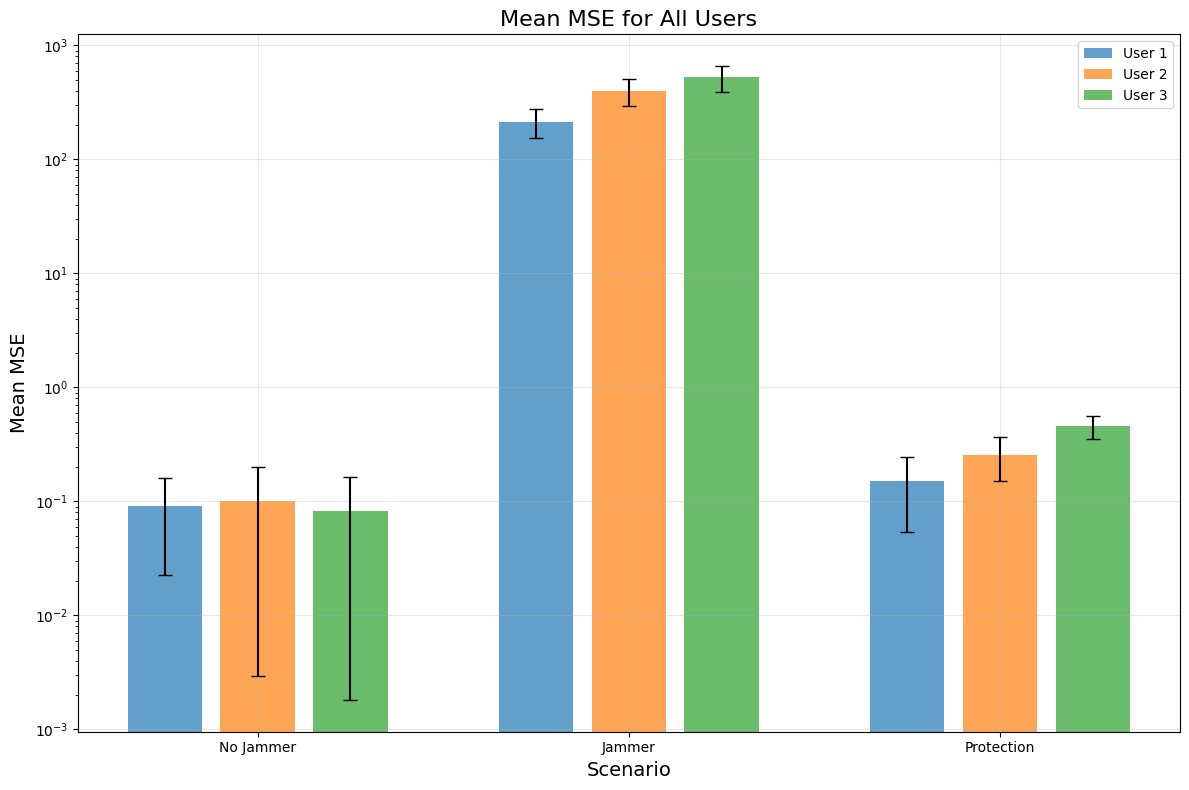

In [14]:
import numpy as np
import matplotlib.pyplot as plt

# Load the MSE data
mse_filepath = '/home/aladin/latest/resilient_sfl/mse_files/'
all_mses_no_jammer = np.load(mse_filepath + 'mse_no_jammer.npy', allow_pickle=True)
all_mses_no_protection = np.load(mse_filepath + 'mse_no_protection.npy', allow_pickle=True)
all_mses_w_protection = np.load(mse_filepath + 'mse_w_protection.npy', allow_pickle=True)

# User collection
user1 = np.array([[a, b, c] for a, b, c in zip(all_mses_no_jammer[:300, 0], all_mses_no_protection[:300, 0], all_mses_w_protection[:300, 0])], dtype=np.float32)
user2 = np.array([[a, b, c] for a, b, c in zip(all_mses_no_jammer[:300, 1], all_mses_no_protection[:300, 1], all_mses_w_protection[:300, 1])], dtype=np.float32)
user3 = np.array([[a, b, c] for a, b, c in zip(all_mses_no_jammer[:300, 2], all_mses_no_protection[:300, 2], all_mses_w_protection[:300, 2])], dtype=np.float32)

def joint_mse_bar_plot(users_data, user_labels):
    """
    Plots a joint bar plot for all users' MSE data.
    
    Parameters:
    - users_data: A list of numpy arrays, each containing MSE data for a user.
    - user_labels: A list of labels for the users.
    """
    labels = ['No Jammer', 'Jammer', 'Protection']
    num_users = len(users_data)
    num_scenarios = len(labels)
    
    # Calculate mean and std MSE values for each user and scenario
    means = np.array([[np.mean(user[:, i]) for i in range(num_scenarios)] for user in users_data])
    stds = np.array([[np.std(user[:, i]) for i in range(num_scenarios)] for user in users_data])
    
    # Bar plot
    x = np.arange(num_scenarios)
    bar_width = 0.2
    spacing = 0.05
    
    fig, ax = plt.subplots(figsize=(12, 8))
    
    for i in range(num_users):
        ax.bar(x + i * (bar_width + spacing), means[i], bar_width, yerr=stds[i], capsize=5,
               label=user_labels[i], alpha=0.7)
    
    # Setting labels and titles
    ax.set_xlabel('Scenario', fontsize=14)
    ax.set_ylabel('Mean MSE', fontsize=14)
    ax.set_title('Mean MSE for All Users', fontsize=16)
    ax.set_xticks(x + (num_users - 1) * (bar_width + spacing) / 2)
    ax.set_xticklabels(labels)
    ax.set_yscale('log')
    ax.grid(True, alpha=0.3)
    ax.legend()
    
    plt.tight_layout()
    plt.show()

# Generate the joint bar plot
users_data = [user1, user2, user3]
user_labels = ["User 1", "User 2", "User 3"]
joint_mse_bar_plot(users_data, user_labels)


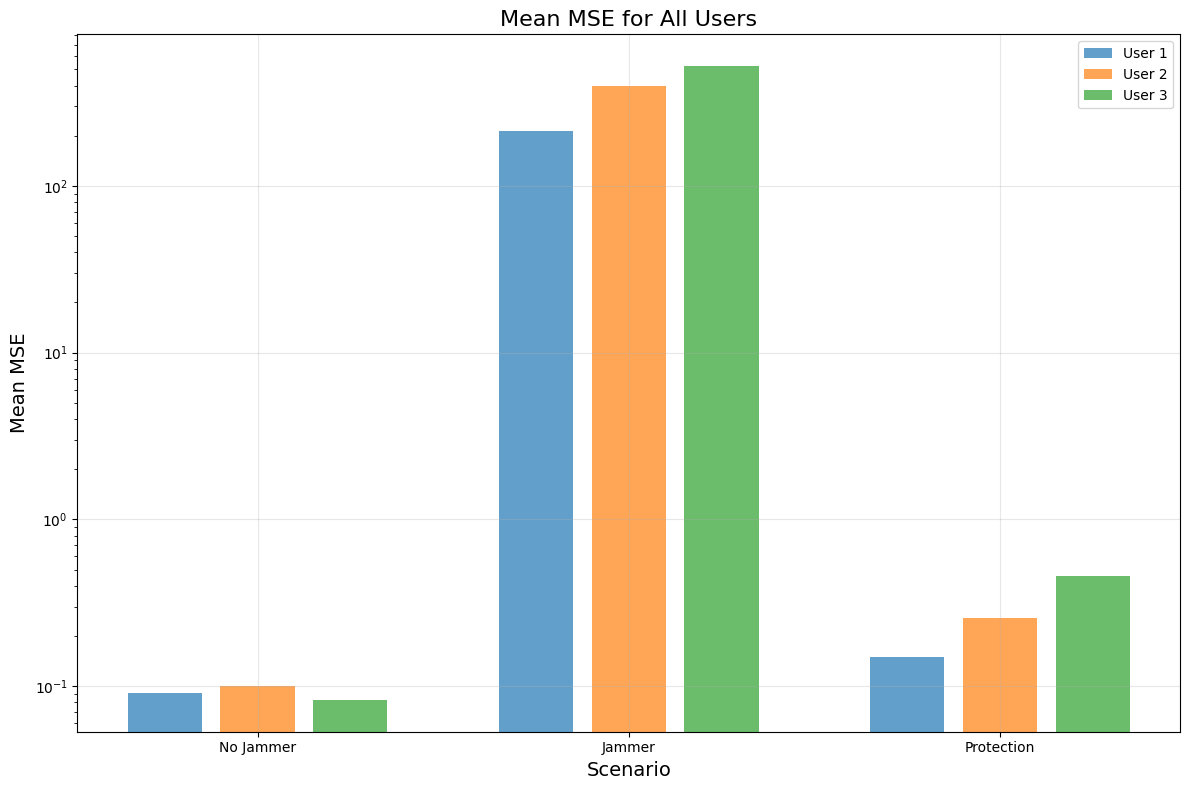

In [15]:
import numpy as np
import matplotlib.pyplot as plt

# Load the MSE data
mse_filepath = '/home/aladin/latest/resilient_sfl/mse_files/'
all_mses_no_jammer = np.load(mse_filepath + 'mse_no_jammer.npy', allow_pickle=True)
all_mses_no_protection = np.load(mse_filepath + 'mse_no_protection.npy', allow_pickle=True)
all_mses_w_protection = np.load(mse_filepath + 'mse_w_protection.npy', allow_pickle=True)

# User collection
user1 = np.array([[a, b, c] for a, b, c in zip(all_mses_no_jammer[:300, 0], all_mses_no_protection[:300, 0], all_mses_w_protection[:300, 0])], dtype=np.float32)
user2 = np.array([[a, b, c] for a, b, c in zip(all_mses_no_jammer[:300, 1], all_mses_no_protection[:300, 1], all_mses_w_protection[:300, 1])], dtype=np.float32)
user3 = np.array([[a, b, c] for a, b, c in zip(all_mses_no_jammer[:300, 2], all_mses_no_protection[:300, 2], all_mses_w_protection[:300, 2])], dtype=np.float32)

def joint_mse_bar_plot(users_data, user_labels):
    """
    Plots a joint bar plot for all users' MSE data.
    
    Parameters:
    - users_data: A list of numpy arrays, each containing MSE data for a user.
    - user_labels: A list of labels for the users.
    """
    labels = ['No Jammer', 'Jammer', 'Protection']
    num_users = len(users_data)
    num_scenarios = len(labels)
    
    # Calculate mean MSE values for each user and scenario
    means = np.array([[np.mean(user[:, i]) for i in range(num_scenarios)] for user in users_data])
    
    # Bar plot
    x = np.arange(num_scenarios)
    bar_width = 0.2
    spacing = 0.05
    
    fig, ax = plt.subplots(figsize=(12, 8))
    
    for i in range(num_users):
        ax.bar(x + i * (bar_width + spacing), means[i], bar_width, 
               label=user_labels[i], alpha=0.7)
    
    # Setting labels and titles
    ax.set_xlabel('Scenario', fontsize=14)
    ax.set_ylabel('Mean MSE', fontsize=14)
    ax.set_title('Mean MSE for All Users', fontsize=16)
    ax.set_xticks(x + (num_users - 1) * (bar_width + spacing) / 2)
    ax.set_xticklabels(labels)
    ax.set_yscale('log')
    ax.grid(True, alpha=0.3)
    ax.legend()
    
    plt.tight_layout()
    plt.show()

# Generate the joint bar plot
users_data = [user1, user2, user3]
user_labels = ["User 1", "User 2", "User 3"]
joint_mse_bar_plot(users_data, user_labels)


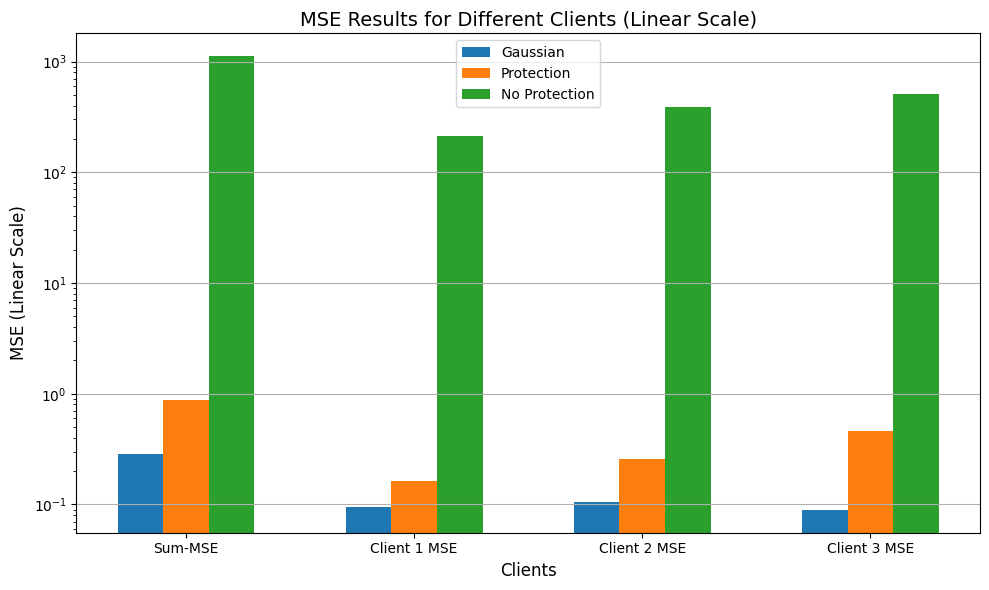

In [4]:
import matplotlib.pyplot as plt
import numpy as np

# Data
scenarios = ["Gaussian", "Protection", "No Protection"]
clients = ["Sum-MSE", "Client 1 MSE", "Client 2 MSE", "Client 3 MSE"]

mse_data_db = [
    [-5.4, -0.56, 30.5],  # Sum-MSE
    [-10.2, -7.9, 23.3],  # Client 1 MSE
    [-9.8, -5.9, 25.9],   # Client 2 MSE
    [-10.5, -3.4, 27.1],  # Client 3 MSE
]

# Convert from dB to linear scale
mse_data_linear = 10 ** (np.array(mse_data_db) / 10)

# Plotting
fig, ax = plt.subplots(figsize=(10, 6))

# Define bar width
bar_width = 0.2
index = np.arange(len(clients))

# Plotting bars for each scenario
for j, scenario in enumerate(scenarios):
    ax.bar(index + bar_width * j, 
           mse_data_linear[:, j], 
           bar_width, label=scenario)

# Setting labels and titles
ax.set_xlabel('Clients', fontsize=12)
ax.set_ylabel('MSE (Linear Scale)', fontsize=12)
ax.set_title('MSE Results for Different Clients (Linear Scale)', fontsize=14)
ax.set_xticks(index + bar_width * (len(scenarios) - 1) / 2)
ax.set_xticklabels(clients)
ax.legend()

# set y-axis to log scale
plt.yscale('log')

plt.grid(axis='y')
plt.tight_layout()
plt.show()


In [5]:

import numpy as np

# Load
mse_filepath = '/home/aladin/latest/resilient_sfl/mse_files/'
all_mses_no_jammer = np.load(mse_filepath + 'mse_no_jammer.npy', allow_pickle=True)
all_mses_no_protection = np.load(mse_filepath + 'mse_no_protection.npy', allow_pickle=True)
all_mses_w_protection = np.load(mse_filepath + 'mse_w_protection.npy', allow_pickle=True)

# User collection
user1 = [[a, b, c] for a, b, c in zip(all_mses_no_jammer[:300, 0], all_mses_no_protection[:300, 0], all_mses_w_protection[:300, 0])]
user2 = [[a, b, c] for a, b, c in zip(all_mses_no_jammer[:300, 1], all_mses_no_protection[:300, 1], all_mses_w_protection[:300, 1])]
user3 = [[a, b, c] for a, b, c in zip(all_mses_no_jammer[:300, 2], all_mses_no_protection[:300, 2], all_mses_w_protection[:300, 2])]

user1 = np.asarray(user1, dtype=np.float32)
user2 = np.asarray(user2, dtype=np.float32)
user3 = np.asarray(user3, dtype=np.float32)


def mse_bar_plot(user_data, user_id):
    """
    Plots a bar plot for the given user's MSE data.
    
    Parameters:
    - user_data: A numpy array of arrays containing three values per entry.
    - user_id: An identifier for the user (e.g., "User 1").
    """
    # Number of entries
    num_entries = user_data.shape[0]
    
    # Calculate mean MSE values for each case
    mean_no_jammer = np.mean(user_data[:, 0])
    mean_jammer = np.mean(user_data[:, 1])
    mean_protection = np.mean(user_data[:, 2])
    
    # Calculate standard deviation for error bars
    std_no_jammer = np.std(user_data[:, 0])
    std_jammer = np.std(user_data[:, 1])
    std_protection = np.std(user_data[:, 2])
    
    # Bar plot
    labels = ['No Jammer', 'Jammer', 'Protection']
    means = [mean_no_jammer, mean_jammer, mean_protection]
    stds = [std_no_jammer, std_jammer, std_protection]
    
    x = np.arange(len(labels))
    
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.bar(x, means, yerr=stds, capsize=5, color=['green', 'red', 'blue'], alpha=0.7)
    
    ax.set_xlabel('Scenario', fontsize=14)
    ax.set_ylabel('Mean MSE', fontsize=14)
    ax.set_title(f'Mean MSE for {user_id}', fontsize=16)
    ax.set_xticks(x)
    ax.set_xticklabels(labels)
    ax.grid(True, alpha=0.3)
    
    plt.show()


def mse_bar_plot_log_scale(user_data, user_id):
    """
    Plots a bar plot for the given user's MSE data using a logarithmic scale.
    
    Parameters:
    - user_data: A numpy array of arrays containing three values per entry.
    - user_id: An identifier for the user (e.g., "User 1").
    """
    # Number of entries
    num_entries = user_data.shape[0]
    
    # Calculate mean MSE values for each case
    mean_no_jammer = np.mean(user_data[:, 0])
    mean_jammer = np.mean(user_data[:, 1])
    mean_protection = np.mean(user_data[:, 2])
    
    # Calculate standard deviation for error bars
    std_no_jammer = np.std(user_data[:, 0])
    std_jammer = np.std(user_data[:, 1])
    std_protection = np.std(user_data[:, 2])
    
    # Bar plot
    labels = ['No Jammer', 'Jammer', 'Protection']
    means = [mean_no_jammer, mean_jammer, mean_protection]
    stds = [std_no_jammer, std_jammer, std_protection]
    
    x = np.arange(len(labels))
    
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.bar(x, means, yerr=stds, capsize=5, color=['green', 'red', 'blue'], alpha=0.7)
    
    ax.set_xlabel('Scenario', fontsize=14)
    ax.set_ylabel('Mean MSE', fontsize=14)
    ax.set_title(f'Mean MSE for {user_id}', fontsize=16)
    ax.set_xticks(x)
    ax.set_xticklabels(labels)
    ax.set_yscale('log')
    ax.grid(True, alpha=0.3)
    
    plt.show()

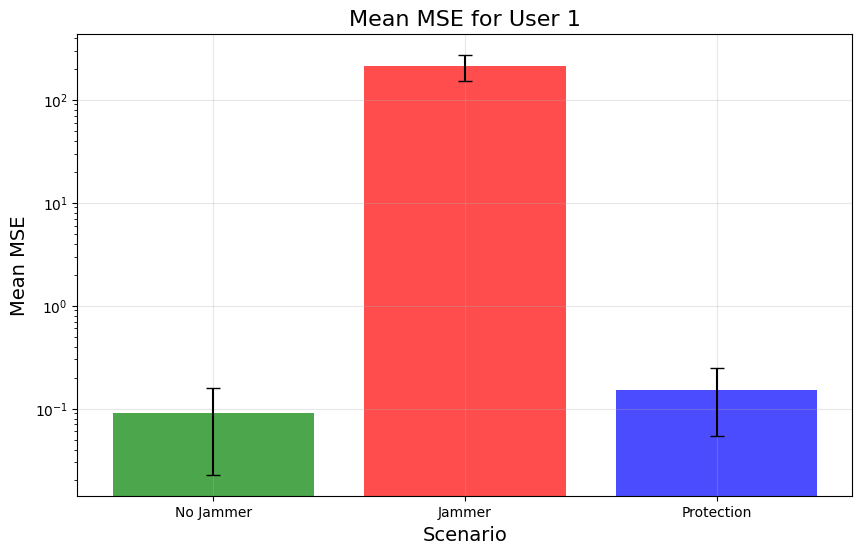

In [6]:
mse_bar_plot_log_scale(user1, "User 1")